# Projet d'Analyse de données



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from skimpy import skim
import seaborn as sns 
import prince
from statsmodels.graphics.mosaicplot import mosaic
from pandas.plotting import scatter_matrix

%matplotlib inline

# Introduction


## Prise en charge et présentation du jeu de données 

In [2]:
# Liste des variables originales et leurs descriptions
variables = {
    "Date": "Date du jour de la donnée",
    "Service": "Type de service ou train",
    "Gare de départ": "Gare de départ",
    "Gare d'arrivée": "Gare d'arrivée",
    "Durée moyenne du trajet": "Durée moyenne du trajet",
    "Nombre de circulations prévues": "Nombre de circulations prévues",
    "Nombre de trains annulés": "Nombre de trains annulés",
    "Nombre de trains en retard au départ": "Nombre de trains en retard au départ",
    "Retard moyen des trains en retard au départ": "Retard moyen des trains en retard au départ",
    "Retard moyen de tous les trains au départ": "Retard moyen de tous les trains au départ",
    "Nombre de trains en retard à l'arrivée": "Nombre de trains en retard à l'arrivée",
    "Retard moyen des trains en retard à l'arrivée": "Retard moyen des trains en retard à l'arrivée",
    "Retard moyen de tous les trains à l'arrivée": "Retard moyen de tous les trains à l'arrivée",
    "Nombre trains en retard > 15min": "Nombre de trains en retard entre 15 et 30 min",
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)": "Retard moyen > 15 min si concurrence aérienne",
    "Nombre trains en retard > 30min": "Nombre de trains en retard entre 30 et 60 min",
    "Nombre trains en retard > 60min": "Nombre de trains en retard de plus de 60 min",
    "Prct retard pour causes externes": "Pourcentage de retard pour causes externes",
    "Prct retard pour cause infrastructure": "Pourcentage de retard pour causes infrastructure",
    "Prct retard pour cause gestion trafic": "Pourcentage de retard pour causes gestion trafic",
    "Prct retard pour cause matériel roulant": "Pourcentage de retard pour causes matériel roulant",
    "Prct retard pour cause gestion en gare et réutilisation de matériel": "Pourcentage de retard pour causes gestion gare / réutilisation matériel",
    "Prct retard pour cause prise en compte voyageurs (affluence": "Pourcentage de retard pour causes affluence voyageurs"
}

# transformer noms plus courts
short_names = {
    "Date": "date",
    "Service": "service",
    "Gare de départ": "dep_station",
    "Gare d'arrivée": "arr_station",
    "Durée moyenne du trajet": "avg_duration",
    "Nombre de circulations prévues": "planned_trains",
    "Nombre de trains annulés": "cancelled_trains",
    "Nombre de trains en retard au départ": "dep_late_trains",
    "Retard moyen des trains en retard au départ": "dep_avg_late",
    "Retard moyen de tous les trains au départ": "dep_avg_all",
    "Nombre de trains en retard à l'arrivée": "arr_late_trains",
    "Retard moyen des trains en retard à l'arrivée": "arr_avg_late",
    "Retard moyen de tous les trains à l'arrivée": "arr_avg_all",
    "Nombre trains en retard > 15min": "late_15",
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)": "late_15_air",
    "Nombre trains en retard > 30min": "late_30",
    "Nombre trains en retard > 60min": "late_60",
    "Prct retard pour causes externes": "pct_external",
    "Prct retard pour cause infrastructure": "pct_infra",
    "Prct retard pour cause gestion trafic": "pct_traffic",
    "Prct retard pour cause matériel roulant": "pct_rolling",
    "Prct retard pour cause gestion en gare et réutilisation de matériel": "pct_station",
    "Prct retard pour cause prise en compte voyageurs (affluence": "pct_passengers"
}

# création DataFrame pour affichage 
df_vars = pd.DataFrame({
    "Variables renommées": [short_names[k] for k in variables.keys()],
    "Description": [variables[k] for k in variables.keys()]
})

print("Chaque individu représente un mois, pour lesquels on observe 23 variables")
display(df_vars.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [dict(selector='th', props=[('text-align', 'left')])]
))


Chaque individu représente un mois, pour lesquels on observe 23 variables


,Variables renommées,Description
0,date,Date du jour de la donnée
1,service,Type de service ou train
2,dep_station,Gare de départ
3,arr_station,Gare d'arrivée
4,avg_duration,Durée moyenne du trajet
5,planned_trains,Nombre de circulations prévues
6,cancelled_trains,Nombre de trains annulés
7,dep_late_trains,Nombre de trains en retard au départ
8,dep_avg_late,Retard moyen des trains en retard au départ
9,dep_avg_all,Retard moyen de tous les trains au départ


In [3]:
data = pd.read_excel('regularite-mensuelle-tgv-aqst_full.ods',engine='odf')
data = data.rename(columns=short_names)


display( 
    data.head().style.background_gradient(cmap='BuPu')
)

/home/alezandre/Documents/4A-ADD/Projet/Projet_AD/.venv/lib/python3.12/site-packages/pandas/io/formats/style.py:4202: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/home/alezandre/Documents/4A-ADD/Projet/Projet_AD/.venv/lib/python3.12/site-packages/pandas/io/formats/style.py:4203: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,date,service,dep_station,arr_station,avg_duration,planned_trains,cancelled_trains,Commentaire annulations,dep_late_trains,dep_avg_late,dep_avg_all,Commentaire retards au départ,arr_late_trains,arr_avg_late,arr_avg_all,Commentaire retards à l'arrivée,late_15,late_15_air,late_30,late_60,pct_external,pct_infra,pct_traffic,pct_rolling,pct_station,pct_passengers,gestions PSH,correspondances),Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,870,5,nan,289,11.247809,3.693179,nan,147,28.436735,6.511118,nan,110,6.511118,44,8,36.134454,31.092437,10.924370,15.966387,5.042017,0.840336,nan,nan,nan,nan,nan,nan,nan
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56,406,1,nan,213,8.479969,4.567119,nan,105,18.049048,5.363539,"Ce mois-ci, l'OD a été touchée par les incidents suivants :Le 1er : Tempête Carmen sur la façade Atlantique (52 TGV ; 1079mn)Le 3 : Tempête Eleonor sur l’ouest de la France (35 TGV ; 407mn)Le 5 : Dérangement d’une aiguille en gare de Massy TGV (57 TGV ; 1254mn)Le 7 : Dérangement du poste d’aiguillage de Paris Montparnasse (70 TGV ; 1490mn)Le 12 : Colis suspect en gare de Paris Montparnasse (32 TGV ; 499mn)Le 12 : Incident caténaire en gare de Rennes (26 TGV ; 2188mn)Le 17 : Dérangement du poste d’aiguillage de Paris Montparnasse (26 TGV ; 386mn)Le 17 : Présence d’une personne dans les voies à Ste Luce (11 TGV ; 212mn)Le 26 : Heurt d’une personne au niveau de Tiercé (44 TGV ; 1578mn)",32,5.363539,9,4,20,35,16.666667,16.666667,8.333333,3.333333,nan,nan,nan,nan,nan,nan,nan
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166,226,0,nan,21,6.239683,0.286283,nan,19,24.736842,2.938053,nan,11,2.938053,6,1,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111,nan,nan,nan,nan,nan,nan,nan
3,2018-01,National,PARIS MONTPARNASSE,NANTES,124,508,3,nan,71,7.235211,0.734290,nan,58,33.726437,5.292211,nan,39,5.292211,18,8,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852,nan,nan,nan,nan,nan,nan,nan
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94,472,4,nan,224,6.784673,3.229701,nan,89,14.592697,4.882372,nan,42,4.882372,10,0,15.789474,45.614035,19.298246,15.789474,1.754386,1.754386,nan,nan,nan,nan,nan,nan,nan


In [4]:
data['moy_retard_train_deja_retard'] = np.where(
    data['dep_late_trains'] > 0, 
    (data['dep_avg_all'] * data['planned_trains']) / data['dep_late_trains'], 
    0  # Valeur par défaut si aucun train n'est en retard
)

In [5]:
data.dtypes

date                                   str
service                                str
dep_station                         object
arr_station                         object
avg_duration                         int64
planned_trains                       int64
cancelled_trains                     int64
Commentaire annulations            float64
dep_late_trains                      int64
dep_avg_late                       float64
dep_avg_all                        float64
Commentaire retards au départ      float64
arr_late_trains                      int64
arr_avg_late                       float64
arr_avg_all                        float64
Commentaire retards à l'arrivée    float64
late_15                              int64
late_15_air                        float64
late_30                              int64
late_60                              int64
pct_external                       float64
pct_infra                          float64
pct_traffic                        float64
pct_rolling

In [5]:
cols_to_drop = [
    c for c in data.columns 
    if c.startswith("Commentaire") 
    or " gestions PSH" in c 
    or "correspondances)" in c
]
data = data.drop(columns=cols_to_drop)
display(
    data.head().style.background_gradient(cmap="BuPu")
)
len(data)

data['date'] = data['date'].astype('category')
data['service'] = data['service'].astype('category')
data['dep_station'] = data['dep_station'].astype('category')
data['arr_station'] = data['arr_station'].astype('category')
skim(data)

/home/alezandre/Documents/4A-ADD/Projet/Projet_AD/.venv/lib/python3.12/site-packages/pandas/io/formats/style.py:4202: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/home/alezandre/Documents/4A-ADD/Projet/Projet_AD/.venv/lib/python3.12/site-packages/pandas/io/formats/style.py:4203: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,date,service,dep_station,arr_station,avg_duration,planned_trains,cancelled_trains,dep_late_trains,dep_avg_late,dep_avg_all,arr_late_trains,arr_avg_late,arr_avg_all,late_15,late_15_air,late_30,late_60,pct_external,pct_infra,pct_traffic,pct_rolling,pct_station,pct_passengers,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,moy_retard_train_deja_retard
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,870,5,289,11.247809,3.693179,147,28.436735,6.511118,110,6.511118,44,8,36.134454,31.092437,10.924370,15.966387,5.042017,0.840336,nan,nan,nan,nan,nan,11.117875
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56,406,1,213,8.479969,4.567119,105,18.049048,5.363539,32,5.363539,9,4,20,35,16.666667,16.666667,8.333333,3.333333,nan,nan,nan,nan,nan,8.705401
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166,226,0,21,6.239683,0.286283,19,24.736842,2.938053,11,2.938053,6,1,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111,nan,nan,nan,nan,nan,3.080952
3,2018-01,National,PARIS MONTPARNASSE,NANTES,124,508,3,71,7.235211,0.734290,58,33.726437,5.292211,39,5.292211,18,8,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852,nan,nan,nan,nan,nan,5.253796
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94,472,4,224,6.784673,3.229701,89,14.592697,4.882372,42,4.882372,10,0,15.789474,45.614035,19.298246,15.789474,1.754386,1.754386,nan,nan,nan,nan,nan,6.805441


╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 11834  │ │ float64     │ 13    │ │ date                  │                                │
│ │ Number of columns │ 22     │ │ int64       │ 5     │ │ service               │                                │
│ └───────────────────┴────────┘ │ category    │ 4     │ │ dep_station           │                                │
│                                └─────────────┴───────┘ │ arr_station           │                                │
│                                                        └───────────────────────┘                                │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column          ┃ NA    ┃ NA %           ┃ mean  ┃ sd    ┃ p0     ┃ p25   ┃ p50   ┃ p75   ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │  avg_duration   │     0 │              0 │ 170.4 │ 87.67 │      0 │    99 │   163 │ 222.8 │   786 │  ▇█▂   │  │
│ │ planned_trains  │     0 │              0 │   271 │   183 │      0 │   150 │   229 │   359 │  1100 │  ▇█▃▁  │  │
│ │ cancelled_train │     0 │              0 │ 8.654 │ 22.64 │      0 │     0 │     2 │     7 │   297 │   █    │  │
│ │        s        │       │                │       │       │        │       │       │       │       │        │  │
│ │ dep_late_trains │     0 │              0 │ 86.14 │ 88.74 │      0 │    21 │    52 │   126 │   596 │  █▂▁   │  │
│ │  dep_avg_late   │     0 │              0 │ 12.26 │  11.8 │      0 │ 6.143 │ 10.33 │  15.7 │ 316.2 │   █    │  │
│ │   dep_avg_all   │     0 │              0 │ 3.125 │ 5.155 │ -229.3 │ 1.202 │ 2.315 │ 3.934 │   115 │     █  │  │
│ │ arr_late_trains │     0 │              0 │ 37.36 │ 31.13 │      0 │    15 │    29 │    51 │   376 │   █▁   │  │
│ │  arr_avg_late   │     0 │              0 │ 35.09 │  15.6 │ -40.11 │  25.7 │ 33.41 │ 42.39 │ 299.6 │   ▁█   │  │
│ │   arr_avg_all   │     0 │              0 │ 6.031 │ 6.988 │ -472.6 │ 3.385 │ 5.335 │ 8.072 │    92 │      █ │  │
│ │   pct_rolling   │     0 │              0 │  18.9 │ 13.63 │      0 │    10 │ 17.07 │ 25.42 │   100 │  █▇▁   │  │
│ │   pct_station   │     0 │              0 │ 7.676 │ 8.469 │      0 │     0 │ 5.882 │ 11.36 │   100 │   █▁   │  │
│ │ pct_passengers  │     0 │              0 │ 7.886 │ 9.787 │      0 │     0 │ 5.263 │ 11.54 │   100 │   █▁   │  │
│ │   Unnamed: 28   │ 11716 │ 99.00287307757 │ 9.312 │ 9.828 │      0 │ 2.749 │  6.25 │ 13.87 │    50 │  █▃▁▁  │  │
│ │                 │       │             31 │       │       │        │       │       │       │       │        │  │
│ │   Unnamed: 29   │ 11747 │ 99.26483015041 │ 9.813 │ 17.58 │      0 │     0 │ 2.041 │ 10.71 │   100 │   █▁   │  │
│ │                 │       │            406 │       │       │        │       │       │       │       │        │  │
│ │   Unnamed: 30   │ 11785 │ 99.58593882034 │ 7.351 │ 10.71 │      0 │     0 │ 2.273 │ 12.94 │    50 │  █▂▁   │  │
│ │                 │       │            815 │       │       │        │       │       │       │       │        │  │
│ │   Unnamed: 31   │ 11811 │ 99.80564475240 │ 2.486 │ 3.624 │      0 │     0 │ 1.333 │ 3.344 │ 15.38 │ █▂▂  ▁ │  │
│ │                 │       │            831 │       │  

## Exploration élémentaire : analyse descriptive

## Analyse descriptive unidimensionnelle

### Exploration JE SAIS PAS TROP COMMENT APPELER CA

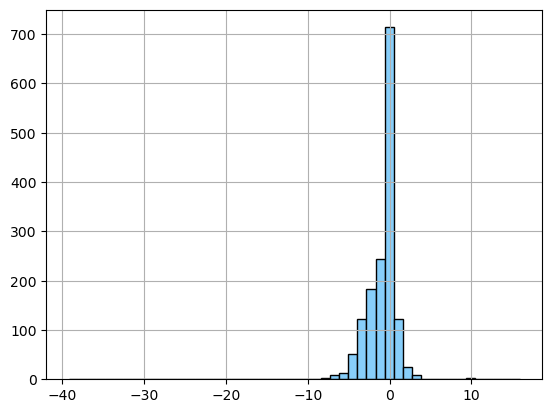

In [20]:
tab.hist(bins=50, color='lightskyblue', edgecolor='black')
plt.show()

<div style="border:2px solid black; padding:10px;">
On constate que la majorité des trains en retard au départ conservent leur retard (grand pic). 
Il y a moins de trains qui rattrapent leur retard (droite) que de trains qui augmentent leur retard (gauche).
 </div>

In [6]:
tab=data['moy_retard_train_deja_retard']-data['dep_avg_late']
moy=0
for i in tab:
    moy+=i
moy=moy/1505
print(moy)

-4.296721993045599


In [10]:
a = 10
train_accumul_retard = data[tab < -a]
print("Trains qui augmentent leur retard de plus de ", a, " minutes :")
for index, row in train_accumul_retard.iterrows():
    print(f"Alerte : {row['dep_station']} - {row['arr_station']} - {row['date']} ont augmenté leur retard au départ de {-(row['moy_retard_train_deja_retard']-row['dep_avg_late']):.2f} minutes.")

b = 5
train_accumul_retard = data[tab < -b]
print("Trains qui rattrapent plus de ", b, " minutes de retard :")
for index, row in train_accumul_retard.iterrows():
    print(f"{row['dep_station']} - {row['arr_station']} - {row['date']} ont rattrapé {-(row['moy_retard_train_deja_retard']-row['dep_avg_late']):.2f} minutes de retard.")

Trains qui augmentent leur retard de plus de  10  minutes :
Alerte : ST MALO - PARIS MONTPARNASSE - 2018-04 ont augmenté leur retard au départ de 19.48 minutes.
Alerte : SAINT ETIENNE CHATEAUCREUX - PARIS LYON - 2018-04 ont augmenté leur retard au départ de 15.75 minutes.
Alerte : GENEVE - PARIS LYON - 2018-05 ont augmenté leur retard au départ de 62.60 minutes.
Alerte : GENEVE - PARIS LYON - 2018-06 ont augmenté leur retard au départ de 60.77 minutes.
Alerte : MADRID - MARSEILLE ST CHARLES - 2018-06 ont augmenté leur retard au départ de 13.00 minutes.
Alerte : PARIS MONTPARNASSE - ST PIERRE DES CORPS - 2018-06 ont augmenté leur retard au départ de 24.32 minutes.
Alerte : PARIS MONTPARNASSE - TOURS - 2018-06 ont augmenté leur retard au départ de 79.17 minutes.
Alerte : GENEVE - PARIS LYON - 2018-07 ont augmenté leur retard au départ de 19.37 minutes.
Alerte : GENEVE - PARIS LYON - 2018-08 ont augmenté leur retard au départ de 22.10 minutes.
Alerte : PARIS LYON - SAINT ETIENNE CHATEAUCR

<div style="border:2px solid black; padding:10px;">
Attention, dans l'histogramme il y a quelques trains qui augmentent leur retard de plus de 10 minutes mais qui ne se voient pas.
 </div>

### 5. Le concurrence aérienne a t-elle un impact sur le nombre de trains en retard ?

### 6. Existe t-il une corrélation entre la date d'un trajet et la cause des retards ? 

# Réduction de dimension linéaire

## Qu'est ce qui pourrait, dans les variables qualitatives, expliquer le retard ? - MCA

Nos individus sont très déterminés par des variables qualitatives (Gare de départ, gare d'arrivée ...). Nous allons donc utiliser la MCA pour étudier les données.

Nous allons tenter de répondre à la question suivte : "Est-ce qu'on peut expliquer le retard 'un train en fonction de la date, du service, de la gare de départ et/ou de la gare d'arrivée ?"

Pour cela nous allons créer une variable qualitative prenant pour valeur 'Jamais', 'Rarement', 'Régulièrement', 'Souvent' en fonction de la proportion de retard sur une liaison et sur un mois.

In [7]:
proportion_retard = (data['arr_late_trains']+data['cancelled_trains']) / data['planned_trains']

bins = [-0.01, 0.05, 0.15, 0.40, 1.0]
labels = ['Jamais', 'Rarement', 'Régulièrement', 'Souvent']

data['retard'] = pd.cut(proportion_retard, bins=bins, labels=labels)

print(data['retard'].value_counts())

retard
Rarement         5461
Régulièrement    5443
Souvent           553
Jamais            304
Name: count, dtype: int64


# Analyse des retards au cours des années

Aperçu de la matrice de contingence :
retard   Jamais  Rarement  Régulièrement  Souvent
periode                                          
2018-01       1        61             68        0
2018-02       3        26             94        7
2018-03       2        57             70        1
2018-04       2         2             38       88
2018-05       1         3             68       58


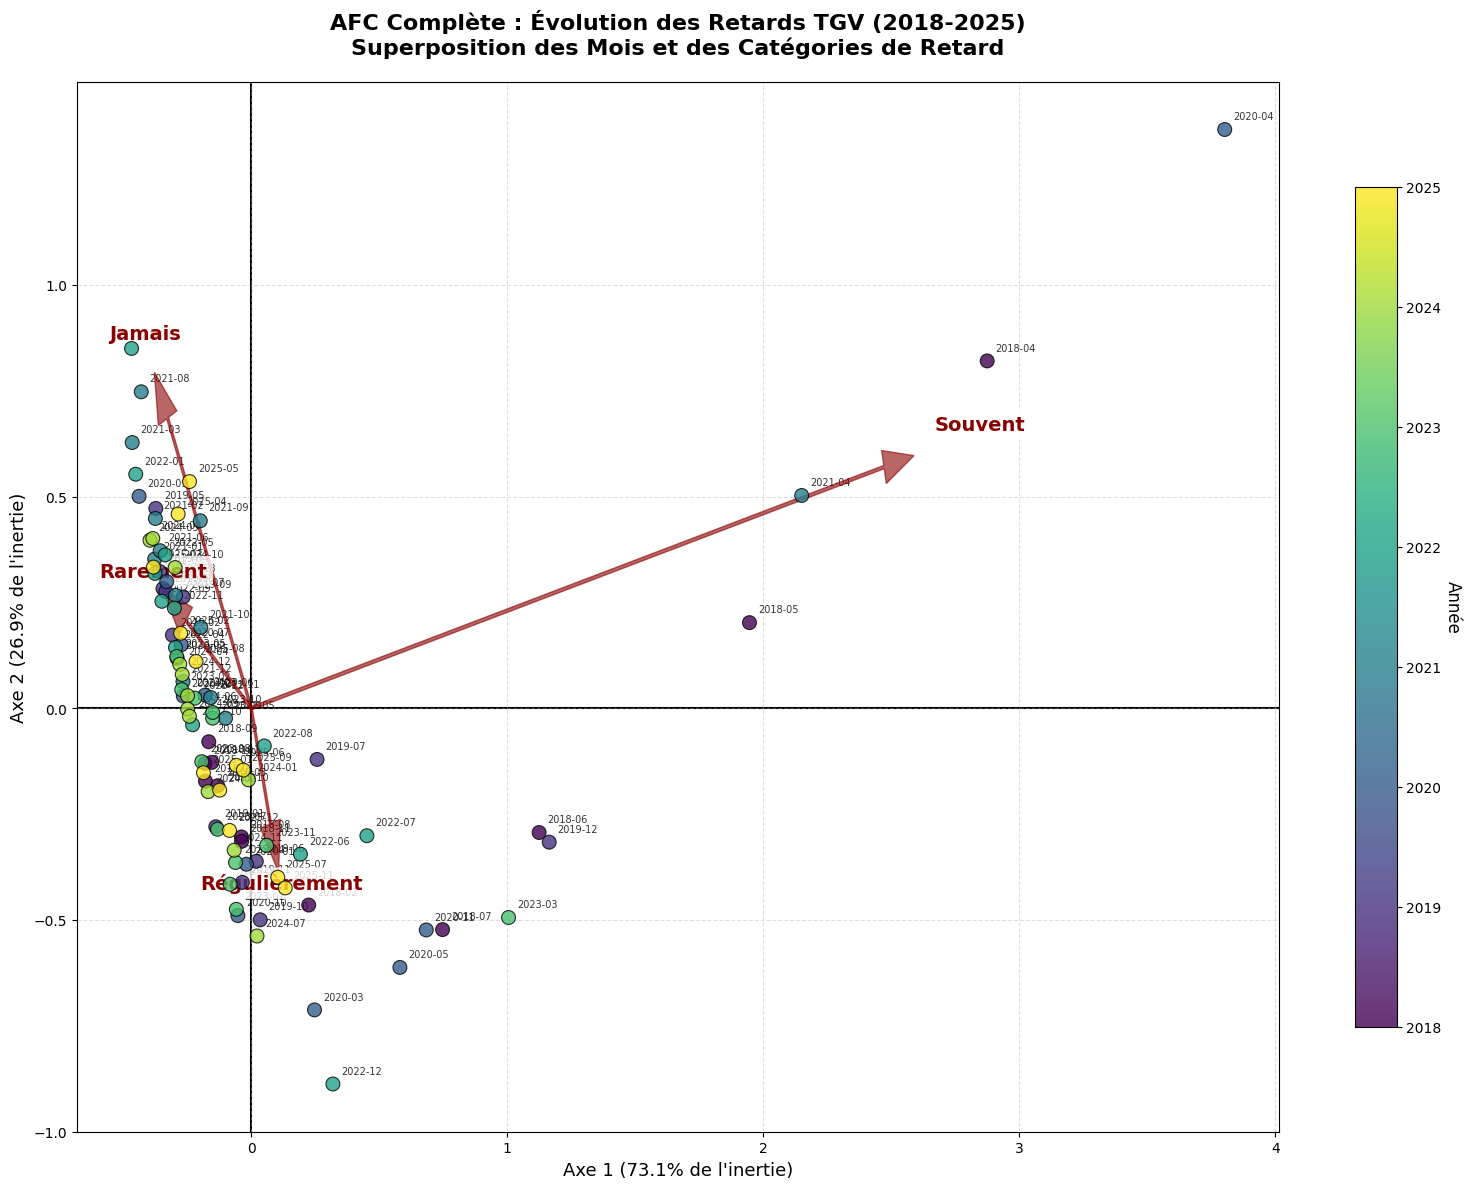


Interprétation : Les mois situés dans la direction d'une flèche (ex: 'Souvent') partagent ce profil de retard.
Axe 1 : 73.1% | Axe 2 : 26.9%


In [12]:
# --- 1. PRÉPARATION DES DONNÉES (VOTRE PARTIE) ---
# On suppose que 'data' est déjà chargé et contient les colonnes 'date' et 'retard'

# Créer la période (assurez-vous que c'est une chaîne de caractères)
data['periode'] = data['date'].astype(str)

# Matrice de contingence
matrice_contingence = data.groupby(['periode', 'retard']).size().unstack(fill_value=0)

# Vérification : s'assurer qu'il n'y a pas de lignes vides
if matrice_contingence.empty:
    raise ValueError("La matrice de contingence est vide. Vérifiez vos colonnes 'date' et 'retard'.")

print("Aperçu de la matrice de contingence :")
print(matrice_contingence.head())

# --- 2. LANCEMENT DE L'AFC ---
afc = prince.CA(n_components=2, n_iter=10, copy=True, check_input=True, random_state=42)
afc = afc.fit(matrice_contingence)

# --- 3. PRÉPARATION DES COORDONNÉES ---
coords_individus = afc.row_coordinates(matrice_contingence)
coords_individus.columns = ['Axe 1', 'Axe 2']

# On convertit l'index en Series pour pouvoir utiliser les méthodes de chaîne
index_series = coords_individus.index.to_series()

# On essaie d'extraire l'année selon deux formats courants
# Cas 1 : "2020-04" (L'année est les 4 premiers caractères)

# On prend les 4 premiers caractères par défaut
annee_candidate = index_series.str[:4]

# On vérifie si c'est bien un nombre (ex: "2020" -> OK, "Avri" -> NaN)
annee_num = pd.to_numeric(annee_candidate, errors='coerce')

# Si c'est NaN, on essaie le format avec underscore (ex: "Avril_2020")
# On prend tout ce qu'il y a après le dernier '_'
mask_nan = annee_num.isna()
if mask_nan.any():
    annee_partie_2 = index_series[mask_nan].str.split('_').str[-1]
    annee_num.loc[mask_nan] = pd.to_numeric(annee_partie_2, errors='coerce')

# On ajoute cette colonne au dataframe des coordonnées
coords_individus['annee_num'] = annee_num

# --- 4. VISUALISATION UNIFIÉE : INDIVIDUS + VARIABLES (MOIS 2018-2025) ---

plt.figure(figsize=(16, 12))

# A. Récupération des coordonnées
coords_individus = afc.row_coordinates(matrice_contingence)
coords_individus.columns = ['Axe 1', 'Axe 2']

coords_variables = afc.column_coordinates(matrice_contingence)
coords_variables.columns = ['Axe 1', 'Axe 2']

# B. Nettoyage de l'année pour la couleur (comme précédemment)
index_series = coords_individus.index.to_series()
annee_candidate = index_series.str[:4]
annee_num = pd.to_numeric(annee_candidate, errors='coerce')
mask_nan = annee_num.isna()
if mask_nan.any():
    annee_partie_2 = index_series[mask_nan].str.split('_').str[-1]
    annee_num.loc[mask_nan] = pd.to_numeric(annee_partie_2, errors='coerce')
coords_individus['annee_num'] = annee_num

# C. Calcul des inerties (pour les titres)
total_inertia = afc.eigenvalues_.sum()
inertie_1 = afc.eigenvalues_[0] / total_inertia
inertie_2 = afc.eigenvalues_[1] / total_inertia

# D. Tracé des VARIABLES (Catégories) en premier plan (flèches)
# On les met en zorder=5 pour qu'elles soient sous les points mais visibles
for i, txt in enumerate(coords_variables.index):
    x = coords_variables['Axe 1'].iloc[i]
    y = coords_variables['Axe 2'].iloc[i]
    
    # Flèche depuis l'origine vers la coordonnée de la variable
    plt.arrow(0, 0, x, y, color='darkred', alpha=0.6, width=0.008, head_width=0.08, length_includes_head=True, zorder=5)
    
    # Nom de la catégorie au bout de la flèche (Fond blanc pour lisibilité)
    plt.text(x*1.1, y*1.1, txt, color='darkred', fontsize=14, fontweight='bold', ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none'), zorder=6)

# E. Tracé des INDIVIDUS (Mois) par dessus
scatter = plt.scatter(
    coords_individus['Axe 1'], 
    coords_individus['Axe 2'], 
    c=coords_individus['annee_num'], 
    cmap='viridis', 
    s=100, 
    alpha=0.8, 
    edgecolors='k', 
    linewidth=0.8,
    label='Mois (colorés par année)',
    zorder=10
)

# Annotation des points (Mois/Année) décalée
for i, txt in enumerate(coords_individus.index):
    x_val = coords_individus['Axe 1'].iloc[i]
    y_val = coords_individus['Axe 2'].iloc[i]
    plt.annotate(txt, (x_val, y_val), 
                 xytext=(6, 6), textcoords='offset points', 
                 fontsize=7, alpha=0.8,
                 ha='left', va='bottom')

# F. Mise en forme finale
plt.title("AFC Complète : Évolution des Retards TGV (2018-2025)\nSuperposition des Mois et des Catégories de Retard", fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f"Axe 1 ({inertie_1:.1%} de l'inertie)", fontsize=13)
plt.ylabel(f"Axe 2 ({inertie_2:.1%} de l'inertie)", fontsize=13)

# Axes centraux et grille
plt.axhline(0, color='black', linewidth=1.5, zorder=1)
plt.axvline(0, color='black', linewidth=1.5, zorder=1)
plt.grid(True, linestyle='--', alpha=0.4, zorder=0)

# Légende de couleur
cbar = plt.colorbar(scatter, shrink=0.8)
cbar.set_label('Année', rotation=270, labelpad=15, fontsize=12)

plt.tight_layout()
plt.show()

print(f"\nInterprétation : Les mois situés dans la direction d'une flèche (ex: 'Souvent') partagent ce profil de retard.")
print(f"Axe 1 : {inertie_1:.1%} | Axe 2 : {inertie_2:.1%}")


Covid : mi fev => mi mai 2020 (avril 2020 normal)


Matrice de contingence Annuelle (8 individus) :
retard     Jamais  Rarement  Régulièrement  Souvent
annee_str                                          
2018           25       434            889      212
2019           39       697            689       51
2020           10       588            698      107
2021           83       851            439       76
2022           64       757            612       34
2023           13       606            792       35
2024           36       772            639        8
2025           34       756            685       30


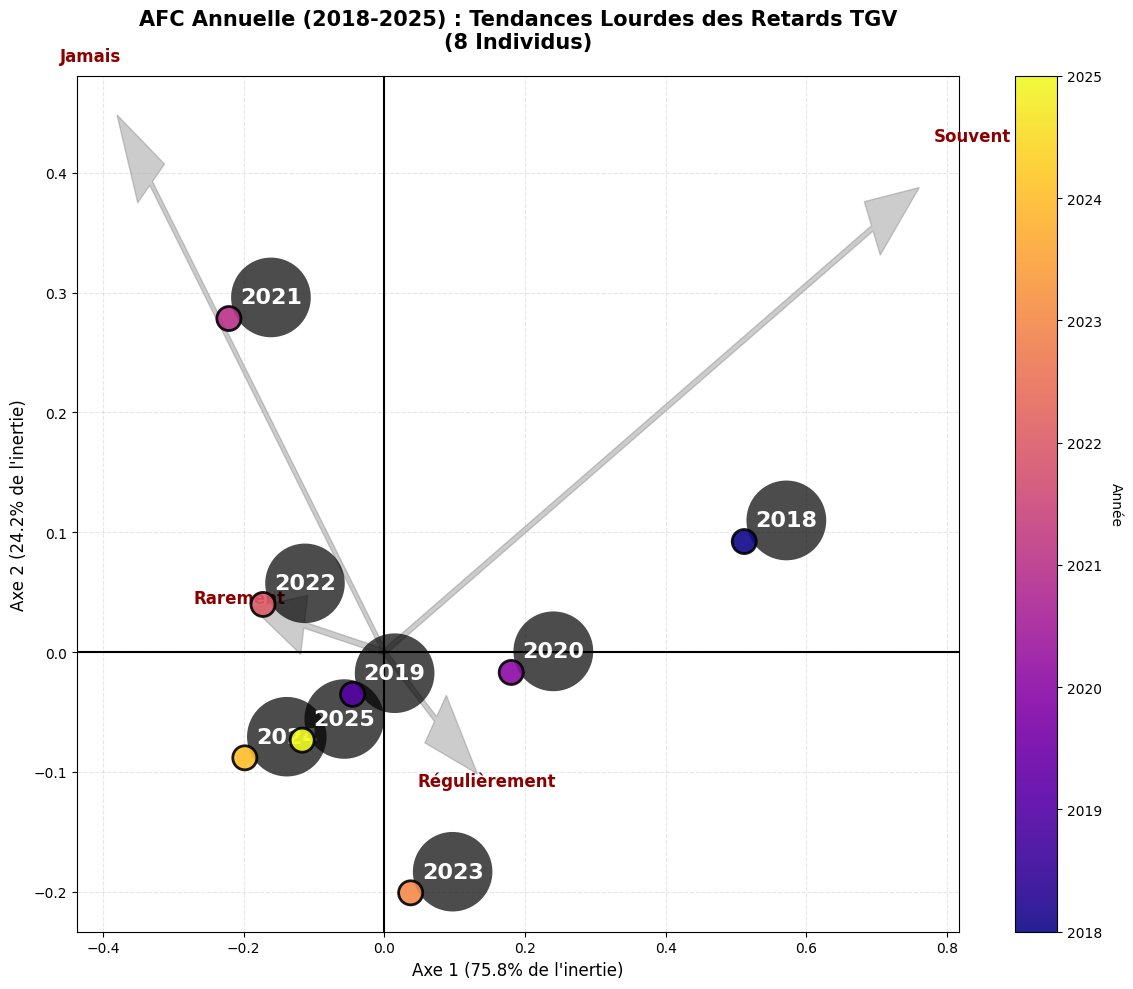


Analyse terminée. Inertie Axe 1: 73.1%, Axe 2: 26.9%


In [13]:
# --- 6. AFC SPÉCIFIQUE PAR ANNÉE (8 Individus) ---

# A. Création de la colonne 'annee' extraite de la date
# On suppose que 'date' est au format 'YYYY-MM' ou datetime. 
# On prend les 4 premiers caractères pour être sûr d'avoir l'année.
data['annee_str'] = data['date'].astype(str).str[:4]

# B. Création de la matrice de contingence par ANNÉE
# Même logique que avant : Groupby (Année, Retard) -> Comptage -> Pivot (unstack)
matrice_annuelle = data.groupby(['annee_str', 'retard']).size().unstack(fill_value=0)

# Optionnel : Réordonner les années si elles sont triées alphabétiquement (ex: 2018, 2019...)
# Cela assure que l'ordre est chronologique même si certaines années manquent dans les données
matrice_annuelle = matrice_annuelle.reindex(sorted(matrice_annuelle.index))

print("\nMatrice de contingence Annuelle (8 individus) :")
print(matrice_annuelle)

# C. Lancement de l'AFC sur les données annuelles
afc_annee = prince.CA(n_components=2, n_iter=10, copy=True, check_input=True, random_state=42)
afc_annee = afc_annee.fit(matrice_annuelle)

# D. Calcul des inerties pour les titres
total_inertia_annee = afc_annee.eigenvalues_.sum()
inertie_a1 = afc_annee.eigenvalues_[0] / total_inertia_annee
inertie_a2 = afc_annee.eigenvalues_[1] / total_inertia_annee

# E. Visualisation
plt.figure(figsize=(12, 10))

# Récupérer les coordonnées des individus (les années)
coords_annees = afc_annee.row_coordinates(matrice_annuelle)
coords_annees.columns = ['Axe 1', 'Axe 2']

# Récupérer les coordonnées des variables (les catégories de retard) pour les superposer
coords_vars_annee = afc_annee.column_coordinates(matrice_annuelle)
coords_vars_annee.columns = ['Axe 1', 'Axe 2']

# 1. Tracer les flèches des variables (Catégories) en fond
for i, txt in enumerate(coords_vars_annee.index):
    x = coords_vars_annee['Axe 1'].iloc[i]
    y = coords_vars_annee['Axe 2'].iloc[i]
    # Flèche depuis l'origine
    plt.arrow(0, 0, x, y, color='gray', alpha=0.4, width=0.005, head_width=0.05, length_includes_head=True)
    # Nom de la catégorie au bout de la flèche
    plt.text(x*1.1, y*1.1, txt, color='darkred', fontsize=12, fontweight='bold', ha='center')

# 2. Tracer les points des ANNÉES par dessus
# On utilise l'index (qui est l'année) converti en entier pour la couleur
coords_annees['annee_num'] = coords_annees.index.astype(int)

scatter_annee = plt.scatter(
    coords_annees['Axe 1'], 
    coords_annees['Axe 2'], 
    c=coords_annees['annee_num'], 
    cmap='plasma',  # Palette de couleurs différente (plus chaude)
    s=300, 
    alpha=0.9, 
    edgecolors='black', 
    linewidth=2,
    zorder=10,
    label='Années'
)

# Ajouter le label de l'année à côté du point
for i, txt in enumerate(coords_annees.index):
    x_val = coords_annees['Axe 1'].iloc[i]
    y_val = coords_annees['Axe 2'].iloc[i]
    # Texte blanc avec contour noir pour lisibilité maximale
    plt.annotate(f"{txt}", (x_val, y_val), 
                 xytext=(8, 8),          # Décalage de 8 points vers le haut-droite
                 textcoords='offset points', # L'unité est en points d'impression (indépendant de l'échelle du graph)
                 ha='left',              # Alignement horizontal à gauche du texte décalé
                 va='bottom',            # Alignement vertical en bas du texte décalé
                 fontsize=16,            # Police un peu plus grande
                 fontweight='bold', 
                 color='white',
                 bbox=dict(boxstyle='circle,pad=0.4', facecolor='black', alpha=0.7, edgecolor='none'))


plt.title("AFC Annuelle (2018-2025) : Tendances Lourdes des Retards TGV\n(8 Individus)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel(f"Axe 1 ({inertie_a1:.1%} de l'inertie)", fontsize=12)
plt.ylabel(f"Axe 2 ({inertie_a2:.1%} de l'inertie)", fontsize=12)

# Grille et axes
plt.axhline(0, color='black', linewidth=1.5)
plt.axvline(0, color='black', linewidth=1.5)
plt.grid(True, linestyle='--', alpha=0.3)

# Légende de couleur
cbar = plt.colorbar(scatter_annee)
cbar.set_label('Année', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

print(f"\nAnalyse terminée. Inertie Axe 1: {inertie_1:.1%}, Axe 2: {inertie_2:.1%}")

> On observe une répartition des individus (vu en tant que un mois d'une année) sur les deux axes avec une forme de "banane" particulière. On n'observe pas de périodes particulièrement concentrées quelque part :

Blabla sur les années

On regarde plus précisements l'année 2018 pour voir si il y a des mois en particulier où les trains ont été plus en retard. 

Matrice de contingence Mensuelle (Agrégat 2018-2025) :
retard    Jamais  Rarement  Régulièrement  Souvent
mois_num                                          
01            15       483            477        6
02            50       542            380        9
03            27       487            436       31
04            28       365            322      218
05            33       491            371       81
06            19       384            528       47
07            12       354            578       53
08            50       559            375       12
09            26       589            366       14
10            16       466            487       10
11            17       348            585       33
12            11       393            538       39

Nombre d'individus : 12 (devrait être 12)


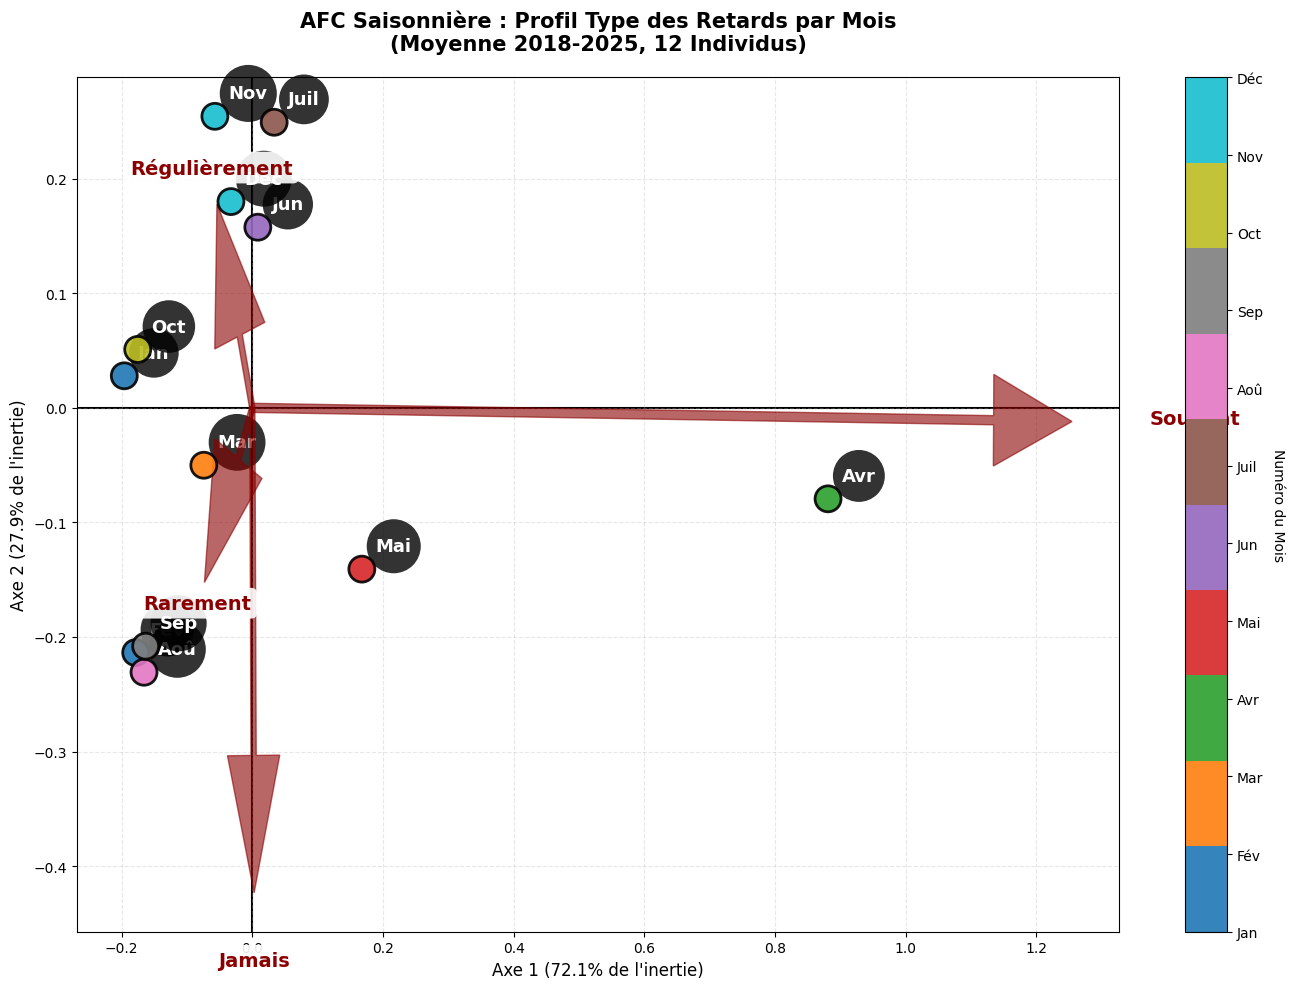


--- Analyse Saisonnière ---
L'axe 1 explique 72.1% des différences entre les mois.
L'axe 2 explique 27.9% des différences entre les mois.
Interprétation : Si 'Juil' et 'Aoû' sont proches de la flèche 'Souvent', les étés sont structurellement plus perturbés.


In [14]:
# --- 8. AFC PAR MOIS (Toutes années confondues - 12 Individus) ---

# A. Préparation : Extraire le numéro du mois pour le regroupement
# On s'assure que la date est en texte, puis on prend la partie après le '-' ou le premier chiffre si format différent
# Hypothèse : format "YYYY-MM" ou "YYYY-MM-DD"
data['mois_num'] = data['date'].astype(str).str.split('-').str[1]

# Vérification de sécurité : s'assurer qu'on a bien des mois de 01 à 12
if data['mois_num'].isna().any():
    # Fallback si le format de date est différent (ex: "01/2018")
    # On essaie de prendre les 2 premiers caractères
    data['mois_num'] = data['date'].astype(str).str[:2]

# Filtrer pour ne garder que les mois valides (01 à 12)
data = data[data['mois_num'].str.match(r'^0[1-9]|1[0-2]$')]

# B. Création de la matrice de contingence par MOIS (Agrégation 2018-2025)
# On groupe par 'mois_num' et 'retard', puis on somme tous les trains de toutes les années pour ce mois.
matrice_mois = data.groupby(['mois_num', 'retard']).size().unstack(fill_value=0)

# Réordonner les mois chronologiquement (01, 02, ..., 12)
# C'est crucial car le tri alphabétique mettrait "10" avant "2"
ordre_mois = [f"{i:02d}" for i in range(1, 13)]
# On ne garde que les mois présents dans les données, dans le bon ordre
mois_presents = [m for m in ordre_mois if m in matrice_mois.index]
matrice_mois = matrice_mois.reindex(mois_presents)

print("Matrice de contingence Mensuelle (Agrégat 2018-2025) :")
print(matrice_mois)
print(f"\nNombre d'individus : {len(matrice_mois)} (devrait être 12)")

# C. Lancement de l'AFC
afc_mois_global = prince.CA(n_components=2, n_iter=10, copy=True, check_input=True, random_state=42)
afc_mois_global = afc_mois_global.fit(matrice_mois)

# D. Calcul des inerties
total_inertia_mois = afc_mois_global.eigenvalues_.sum()
inertie_mm1 = afc_mois_global.eigenvalues_[0] / total_inertia_mois
inertie_mm2 = afc_mois_global.eigenvalues_[1] / total_inertia_mois

# E. Visualisation Unifiée (Mois + Variables)
plt.figure(figsize=(14, 10))

# 1. Coordonnées des individus (les 12 mois)
coords_mois_glob = afc_mois_global.row_coordinates(matrice_mois)
coords_mois_glob.columns = ['Axe 1', 'Axe 2']

# 2. Coordonnées des variables (Catégories de retard)
coords_vars_mois = afc_mois_global.column_coordinates(matrice_mois)
coords_vars_mois.columns = ['Axe 1', 'Axe 2']

# 3. Tracé des VARIABLES (Flèches)
for i, txt in enumerate(coords_vars_mois.index):
    x = coords_vars_mois['Axe 1'].iloc[i]
    y = coords_vars_mois['Axe 2'].iloc[i]
    plt.arrow(0, 0, x, y, color='darkred', alpha=0.6, width=0.008, head_width=0.08, length_includes_head=True, zorder=5)
    plt.text(x*1.15, y*1.15, txt, color='darkred', fontsize=14, fontweight='bold', ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='none'), zorder=6)

# 4. Tracé des INDIVIDUS (Les Mois 01-12)
# On convertit l'index (ex: "04") en entier (4) pour la couleur
coords_mois_glob['mois_int'] = coords_mois_glob.index.astype(int)

scatter_mois_glob = plt.scatter(
    coords_mois_glob['Axe 1'], 
    coords_mois_glob['Axe 2'], 
    c=coords_mois_glob['mois_int'],  # Couleur basée sur le numéro du mois
    cmap='tab10',  # Palette qualitative distincte pour chaque mois
    s=350, 
    alpha=0.9, 
    edgecolors='black', 
    linewidth=2,
    zorder=10,
    label='Mois (Moyenne 2018-2025)'
)

# 5. Annotation des points (Nom du mois)
# Petit dictionnaire pour afficher les noms en toutes lettres
noms_mois = {
    '01': 'Jan', '02': 'Fév', '03': 'Mar', '04': 'Avr', '05': 'Mai', '06': 'Jun',
    '07': 'Juil', '08': 'Aoû', '09': 'Sep', '10': 'Oct', '11': 'Nov', '12': 'Déc'
}

for i, txt in enumerate(coords_mois_glob.index):
    label = noms_mois.get(txt, txt) # Affiche "Jan" au lieu de "01"
    x_val = coords_mois_glob['Axe 1'].iloc[i]
    y_val = coords_mois_glob['Axe 2'].iloc[i]
    
    plt.annotate(label, (x_val, y_val), 
                 xytext=(10, 10),          # Décalage plus important car les points sont gros
                 textcoords='offset points', 
                 ha='left', 
                 va='bottom', 
                 fontsize=13, 
                 fontweight='bold', 
                 color='white',
                 bbox=dict(boxstyle='circle,pad=0.5', facecolor='black', alpha=0.8, edgecolor='none'))

# F. Mise en forme
plt.title("AFC Saisonnière : Profil Type des Retards par Mois\n(Moyenne 2018-2025, 12 Individus)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel(f"Axe 1 ({inertie_mm1:.1%} de l'inertie)", fontsize=12)
plt.ylabel(f"Axe 2 ({inertie_mm2:.1%} de l'inertie)", fontsize=12)

plt.axhline(0, color='black', linewidth=1.5, zorder=1)
plt.axvline(0, color='black', linewidth=1.5, zorder=1)
plt.grid(True, linestyle='--', alpha=0.3, zorder=0)

# Légende de couleur
cbar = plt.colorbar(scatter_mois_glob, ticks=range(1, 13))
cbar.set_label('Numéro du Mois', rotation=270, labelpad=15)
# Optionnel : Renommer les ticks de la barre de couleur
cbar.set_ticklabels(['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc'])

plt.tight_layout()
plt.show()

print(f"\n--- Analyse Saisonnière ---")
print(f"L'axe 1 explique {inertie_mm1:.1%} des différences entre les mois.")
print(f"L'axe 2 explique {inertie_mm2:.1%} des différences entre les mois.")
print("Interprétation : Si 'Juil' et 'Aoû' sont proches de la flèche 'Souvent', les étés sont structurellement plus perturbés.")

Lien avec les vacances ?
Noel en Decembre ?
k-means / cluster autre methodes

## AFM sur les années

Préparation des données pour l'AFCM (désagrégation)...
Nombre d'individus (trains) pour l'AFCM : 11761
Nombre de variables : 3 (annee_var, mois_var, retard)
  annee_var mois_var    retard
0      2018       01    Jamais
1      2018       01  Rarement
2      2018       01  Rarement
3      2018       01  Rarement
4      2018       01  Rarement


AttributeError: 'MCA' object has no attribute 'explained_inertia_'

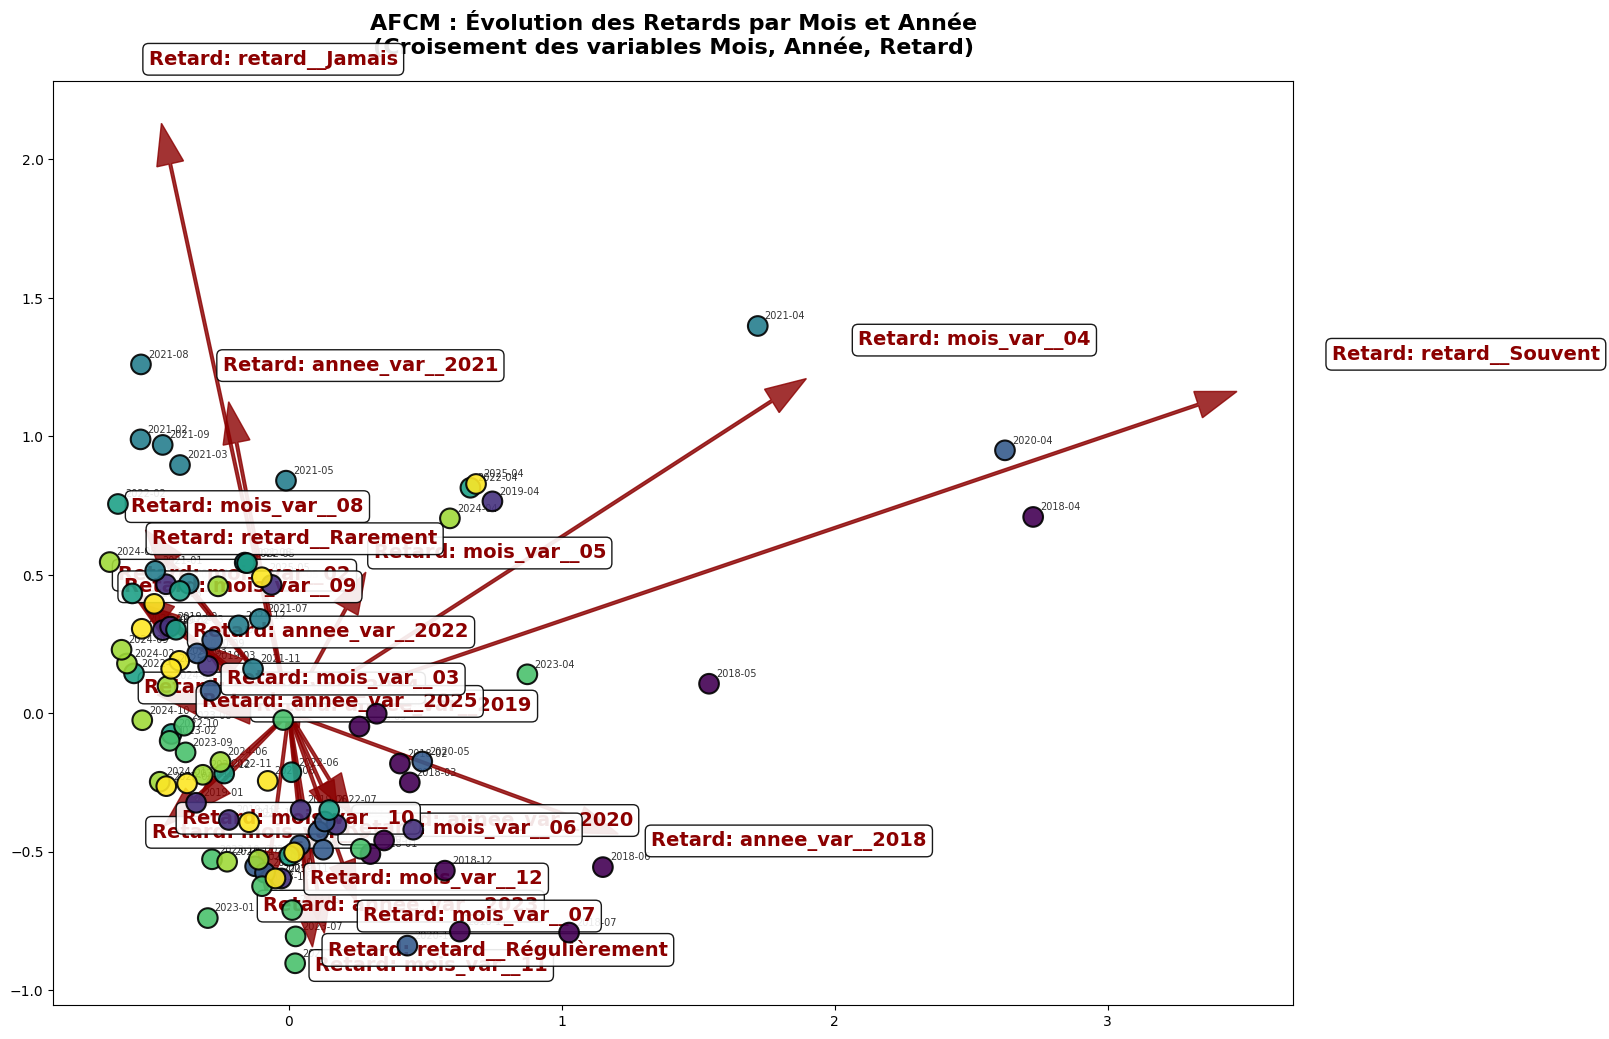

In [15]:
import pandas as pd
import prince
import matplotlib.pyplot as plt
import numpy as np

# --- 1. PRÉPARATION : DÉSAGRÉGATION DES DONNÉES (Étape Cruciale pour l'AFCM) ---
# L'AFCM travaille sur des observations unitaires, pas des comptages.
# Nous allons transformer chaque "comptage" en N lignes individuelles.

print("Préparation des données pour l'AFCM (désagrégation)...")

# On s'assure d'avoir les colonnes séparées
data_prep = data.copy()
data_prep['annee_var'] = data_prep['date'].astype(str).str[:4]
data_prep['mois_var'] = data_prep['date'].astype(str).str.split('-').str[1]

# On crée une colonne 'count' si elle n'existe pas (au cas où votre data est déjà agrégé)
# Si votre data 'data' est déjà au niveau "un train par ligne", cette étape de groupby n'est pas nécessaire,
# mais pour être sûr, on part du principe qu'il faut compter puis exploser.
# Si 'data' est déjà brut (1 ligne = 1 train), sautez le groupby et utilisez directement data_prep.

# Hypothèse : 'data' contient les colonnes 'date', 'retard' et potentiellement d'autres.
# Si 'data' est brut (1 ligne = 1 observation), on saute l'étape de comptage.
# Vérifions si on a des doublons ou si c'est déjà désagrégé.
# Pour cet exemple, on va supposer qu'on doit créer le tableau expansé manuellement pour être sûr du poids.

# Méthode robuste : Groupby pour compter, puis explode pour désagréger
df_counts = data_prep.groupby(['annee_var', 'mois_var', 'retard']).size().reset_index(name='count')

# Création de la liste pour l'explosion
rows = []
for _, row in df_counts.iterrows():
    # On crée 'count' copies de cette ligne
    for _ in range(int(row['count'])):
        rows.append({
            'annee_var': row['annee_var'],
            'mois_var': row['mois_var'],
            'retard': row['retard']
        })

# Création du dataframe désagrégé (1 ligne = 1 train)
df_mca = pd.DataFrame(rows)

print(f"Nombre d'individus (trains) pour l'AFCM : {len(df_mca)}")
print(f"Nombre de variables : 3 (annee_var, mois_var, retard)")
print(df_mca.head())

# --- 2. LANCEMENT DE L'AFCM (MCA) ---
# On sélectionne uniquement les colonnes qualitatives
colonnes_qualitatives = ['annee_var', 'mois_var', 'retard']

mca = prince.MCA(n_components=2, n_iter=10, copy=True, check_input=True, random_state=42)
mca = mca.fit(df_mca[colonnes_qualitatives])

# --- 3. VISUALISATION : PLAN FACTORIEL DES INDIVIDUS (Mois-Année) + VARIABLES ---

plt.figure(figsize=(16, 12))

# A. Coordonnées des Individus (Chaque point est un train, mais on veut voir les groupes Mois-Année)
# Note: Avec beaucoup de points (milliers de trains), le graphique sera un nuage dense.
# Pour voir les "Mois-Année", on va calculer le barycentre (centre de gravité) de chaque groupe.
coords_ind = mca.row_coordinates(df_mca[colonnes_qualitatives])
coords_ind.columns = ['Axe 1', 'Axe 2']

# Ajout des variables pour colorier/filtrer
coords_ind['annee'] = df_mca['annee_var'].values
coords_ind['mois'] = df_mca['mois_var'].values
coords_ind['groupe'] = coords_ind['annee'] + '-' + coords_ind['mois']

# Calcul des barycentres par Groupe (Mois-Année) pour avoir un point lisible par période
barycentres = coords_ind.groupby('groupe')[['Axe 1', 'Axe 2']].mean()
barycentres['annee_num'] = barycentres.index.str[:4].astype(int)

# B. Coordonnées des Variables (Les modalités : "2018", "2019", "Jan", "Fév", "Jamais", "Souvent"...)
coords_vars = mca.column_coordinates(df_mca[colonnes_qualitatives])
coords_vars.columns = ['Axe 1', 'Axe 2']

# Séparation des variables par type pour le style
vars_annees = coords_vars[coords_vars.index.str.len() == 4] # Ex: "2018"
vars_mois = coords_vars[coords_vars.index.str.len() == 2]   # Ex: "01"
vars_retard = coords_vars[~coords_vars.index.isin(vars_annees.index) & ~coords_vars.index.isin(vars_mois.index)]

# --- TRACÉ ---

# 1. Flèches des Variables (Retard) - En Rouge (Le plus important pour votre analyse)
for i, txt in enumerate(vars_retard.index):
    x, y = vars_retard['Axe 1'].iloc[i], vars_retard['Axe 2'].iloc[i]
    plt.arrow(0, 0, x, y, color='darkred', alpha=0.8, width=0.01, head_width=0.1, length_includes_head=True, zorder=5)
    plt.text(x*1.1, y*1.1, f"Retard: {txt}", color='darkred', fontsize=14, fontweight='bold', 
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9), zorder=6)

# 2. Flèches des Variables (Mois) - En Bleu
for i, txt in enumerate(vars_mois.index):
    x, y = vars_mois['Axe 1'].iloc[i], vars_retard['Axe 2'].iloc[i] # Correction: utiliser vars_mois
    x, y = vars_mois['Axe 1'].iloc[i], vars_mois['Axe 2'].iloc[i]
    plt.arrow(0, 0, x, y, color='blue', alpha=0.4, width=0.005, head_width=0.05, length_includes_head=True, zorder=4)
    plt.text(x*1.1, y*1.1, txt, color='blue', fontsize=10, fontweight='bold', alpha=0.7, zorder=5)

# 3. Flèches des Variables (Années) - En Vert
for i, txt in enumerate(vars_annees.index):
    x, y = vars_annees['Axe 1'].iloc[i], vars_annees['Axe 2'].iloc[i]
    plt.arrow(0, 0, x, y, color='green', alpha=0.4, width=0.005, head_width=0.05, length_includes_head=True, zorder=4)
    plt.text(x*1.1, y*1.1, txt, color='green', fontsize=10, fontweight='bold', alpha=0.7, zorder=5)

# 4. Points des Individus (Barycentres Mois-Année)
scatter = plt.scatter(
    barycentres['Axe 1'], 
    barycentres['Axe 2'], 
    c=barycentres['annee_num'], 
    cmap='viridis', 
    s=200, 
    alpha=0.9, 
    edgecolors='black', 
    linewidth=1.5,
    label='Mois-Année (Barycentre)',
    zorder=10
)

# Annotation des points (ex: "01-2018")
for i, txt in enumerate(barycentres.index):
    x, y = barycentres['Axe 1'].iloc[i], barycentres['Axe 2'].iloc[i]
    plt.annotate(txt, (x, y), xytext=(5, 5), textcoords='offset points', fontsize=7, alpha=0.8)

# Mise en forme
plt.title("AFCM : Évolution des Retards par Mois et Année\n(Croisement des variables Mois, Année, Retard)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f"Axe 1 ({mca.explained_inertia_[0]:.1%})") # Note: MCA utilise aussi explained_inertia_ dans les versions récentes
plt.ylabel(f"Axe 2 ({mca.explained_inertia_[1]:.1%})")

# Gestion de l'affichage des inerties (compatibilité versions prince)
try:
    inertie_1 = mca.explained_inertia_[0]
    inertie_2 = mca.explained_inertia_[1]
    plt.xlabel(f"Axe 1 ({inertie_1:.1%})")
    plt.ylabel(f"Axe 2 ({inertie_2:.1%})")
except AttributeError:
    # Fallback si version ancienne
    total_inertia = mca.eigenvalues_.sum()
    inertie_1 = mca.eigenvalues_[0] / total_inertia
    inertie_2 = mca.eigenvalues_[1] / total_inertia
    plt.xlabel(f"Axe 1 ({inertie_1:.1%})")
    plt.ylabel(f"Axe 2 ({inertie_2:.1%})")

plt.axhline(0, color='black', linewidth=1.5)
plt.axvline(0, color='black', linewidth=1.5)
plt.grid(True, linestyle='--', alpha=0.3)

cbar = plt.colorbar(scatter)
cbar.set_label('Année', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

print("\nLégende des flèches :")
print("- Rouge : Catégories de retard (ex: 'Souvent'). Les points proches ont ce profil.")
print("- Bleu : Mois (ex: '01').")
print("- Vert : Années (ex: '2018').")
print("\nInterprétation : Regardez la trajectoire des points '01-2018', '01-2019', etc. pour voir l'évolution de Janvier.")

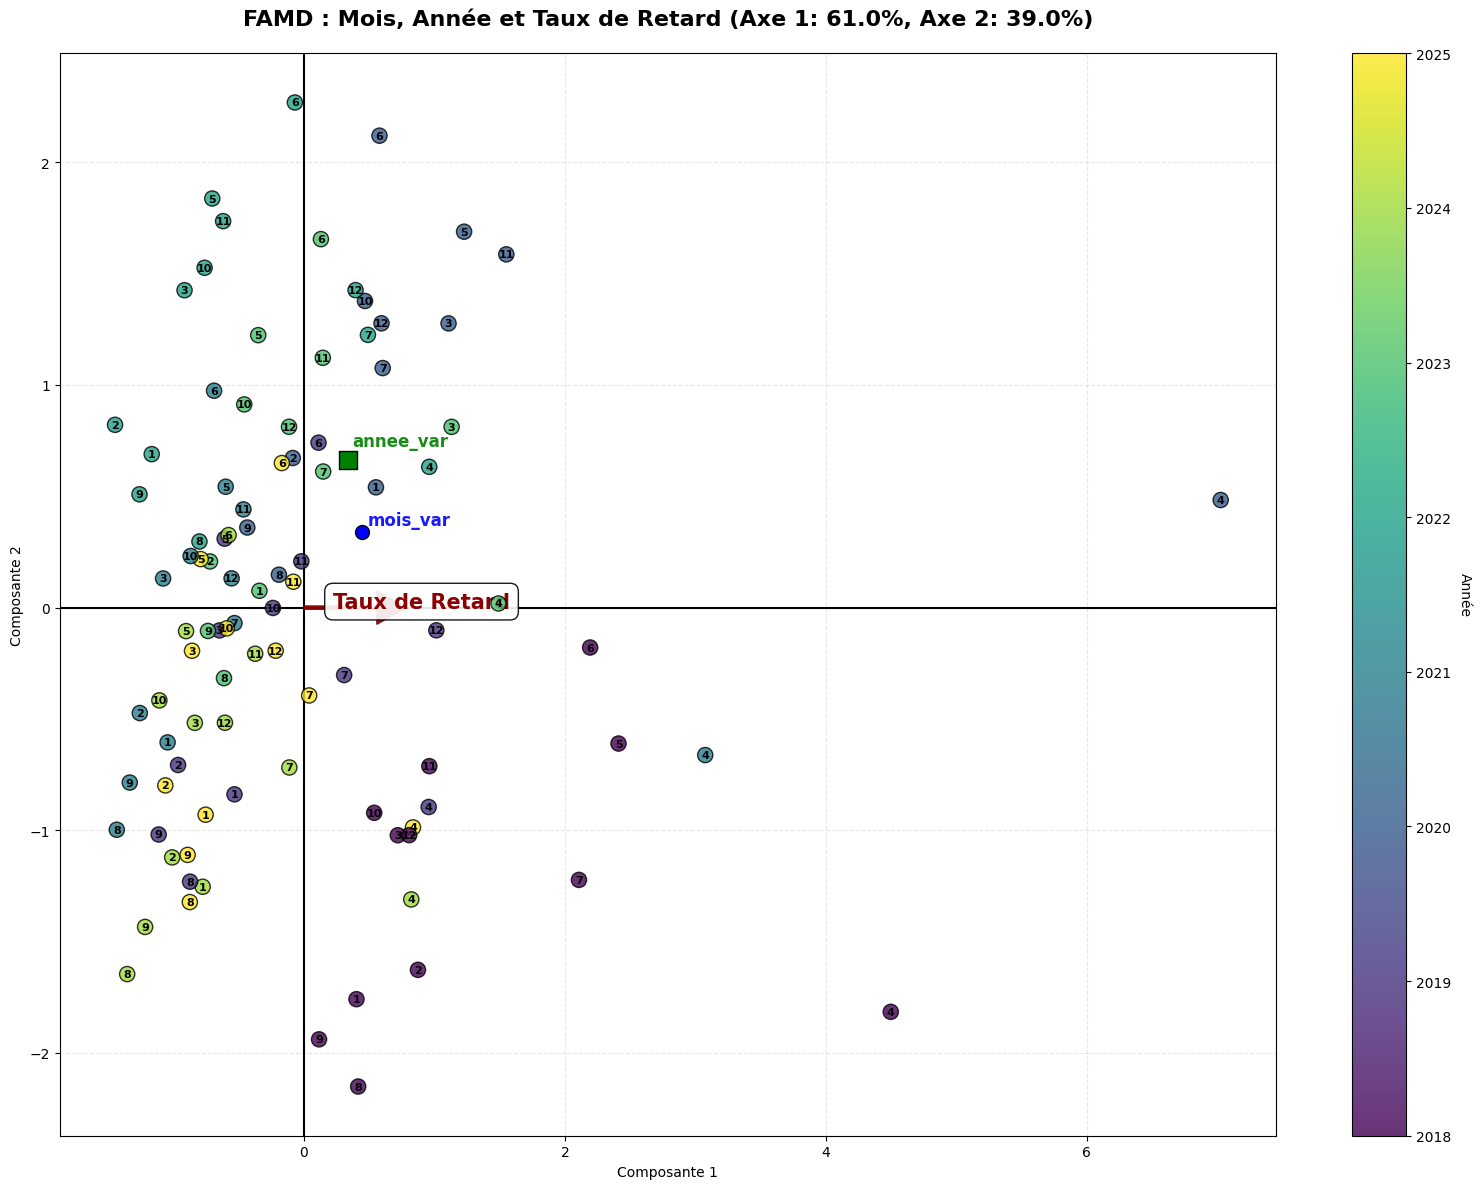

Succès ! Syntaxe mixte appliquée : row_coordinates(df) et column_coordinates_.


In [36]:
# --- 1. PRÉPARATION DES DONNÉES ---
df_famd = data.copy()

df_famd['date_str'] = df_famd['date'].astype(str)
df_famd['annee_var'] = df_famd['date_str'].str[:4].astype('object') 
df_famd['mois_var'] = df_famd['date_str'].str.split('-').str[1].astype('object') 
df_famd['individu'] = df_famd['mois_var'] + '-' + df_famd['annee_var']

agg_data = df_famd.groupby(['individu', 'mois_var', 'annee_var']).agg({
    'arr_late_trains': 'sum',
    'cancelled_trains': 'sum',
    'planned_trains': 'sum'
}).reset_index()

agg_data['proportion_retard'] = (agg_data['arr_late_trains'] + agg_data['cancelled_trains']) / agg_data['planned_trains'].replace(0, np.nan)
agg_data['proportion_retard'] = agg_data['proportion_retard'].fillna(0).astype('float')

df_final = agg_data[['individu', 'mois_var', 'annee_var', 'proportion_retard']].copy()
df_final.set_index('individu', inplace=True)

# --- 2. LANCEMENT DE LA FAMD ---
famd = prince.FAMD(n_components=2, n_iter=10, copy=True, check_input=True, random_state=42)
famd = famd.fit(df_final)

# --- 3. RÉCUPÉRATION DES COORDONNÉES (SYNTAXE MIXTE) ---

# A. Individus (Lignes) : MÉTHODE à appeler avec le dataset
# Syntaxe : objet.methode(dataset)
coords_ind = famd.row_coordinates(df_final).copy()
coords_ind.columns = ['Axe 1', 'Axe 2']

# B. Variables (Colonnes) : ATTRIBUT à lire directement
# Syntaxe : objet.attribut_
coords_var = famd.column_coordinates_.copy()
coords_var.columns = ['Axe 1', 'Axe 2']

# Préparation des données pour le graphique
coords_ind['annee_num'] = coords_ind.index.str.split('-').str[1].astype(int)
coords_ind['mois_num'] = coords_ind.index.str.split('-').str[0].astype(int)

# Séparation Quantitatif / Qualitatif
if 'proportion_retard' in coords_var.index:
    var_quant = coords_var.loc[['proportion_retard']]
    var_qual = coords_var.drop('proportion_retard')
else:
    # Fallback si le nom est légèrement différent
    print(f"Variables trouvées : {coords_var.index.tolist()}")
    var_quant = coords_var.iloc[[0]] 
    var_qual = coords_var.iloc[1:]

# --- 4. VISUALISATION ---
plt.figure(figsize=(16, 12))

# 1. Flèche Variable QUANTITATIVE (Rouge)
x_q, y_q = var_quant['Axe 1'].iloc[0], var_quant['Axe 2'].iloc[0]
plt.arrow(0, 0, x_q, y_q, color='darkred', alpha=0.9, width=0.015, head_width=0.15, length_includes_head=True, zorder=5)
plt.text(x_q*1.15, y_q*1.15, "Taux de Retard", color='darkred', fontsize=15, fontweight='bold', 
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9), zorder=6, ha='center')

# 2. Points Variables QUALITATIVES (Bleu/Vert)
for idx, row in var_qual.iterrows():
    x, y = row['Axe 1'], row['Axe 2']
    label = str(idx)
    
    if 'annee_var' in label:
        color, marker, size = 'green', 's', 150
        label_clean = label.replace('annee_var_', '')
    elif 'mois_var' in label:
        color, marker, size = 'blue', 'o', 100
        label_clean = label.replace('mois_var_', '')
    else:
        continue
        
    plt.scatter(x, y, c=color, s=size, marker=marker, edgecolors='black', zorder=4)
    plt.text(x*1.1, y*1.1, label_clean, color=color, fontsize=12, fontweight='bold', alpha=0.9, zorder=5)

# 3. Individus (Nuage de points)
scatter = plt.scatter(
    coords_ind['Axe 1'], coords_ind['Axe 2'], 
    c=coords_ind['annee_num'], cmap='viridis', s=120, alpha=0.8, 
    edgecolors='black', zorder=10
)

# Annotation (Numéro du mois)
for i, row in coords_ind.iterrows():
    plt.text(row['Axe 1'], row['Axe 2'], str(int(row['mois_num'])), 
             fontsize=8, ha='center', va='center', fontweight='bold', zorder=11)

# Titres et Inerties
total_inertia = famd.eigenvalues_.sum()
inertie_1 = famd.eigenvalues_[0] / total_inertia
inertie_2 = famd.eigenvalues_[1] / total_inertia

plt.title(f"FAMD : Mois, Année et Taux de Retard (Axe 1: {inertie_1:.1%}, Axe 2: {inertie_2:.1%})", fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f"Composante 1")
plt.ylabel(f"Composante 2")
plt.axhline(0, color='black', linewidth=1.5)
plt.axvline(0, color='black', linewidth=1.5)
plt.grid(True, linestyle='--', alpha=0.3)

cbar = plt.colorbar(scatter)
cbar.set_label('Année', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

print("Succès ! Syntaxe mixte appliquée : row_coordinates(df) et column_coordinates_.")

couleur différentes pour les mois / formes différentes pour les années

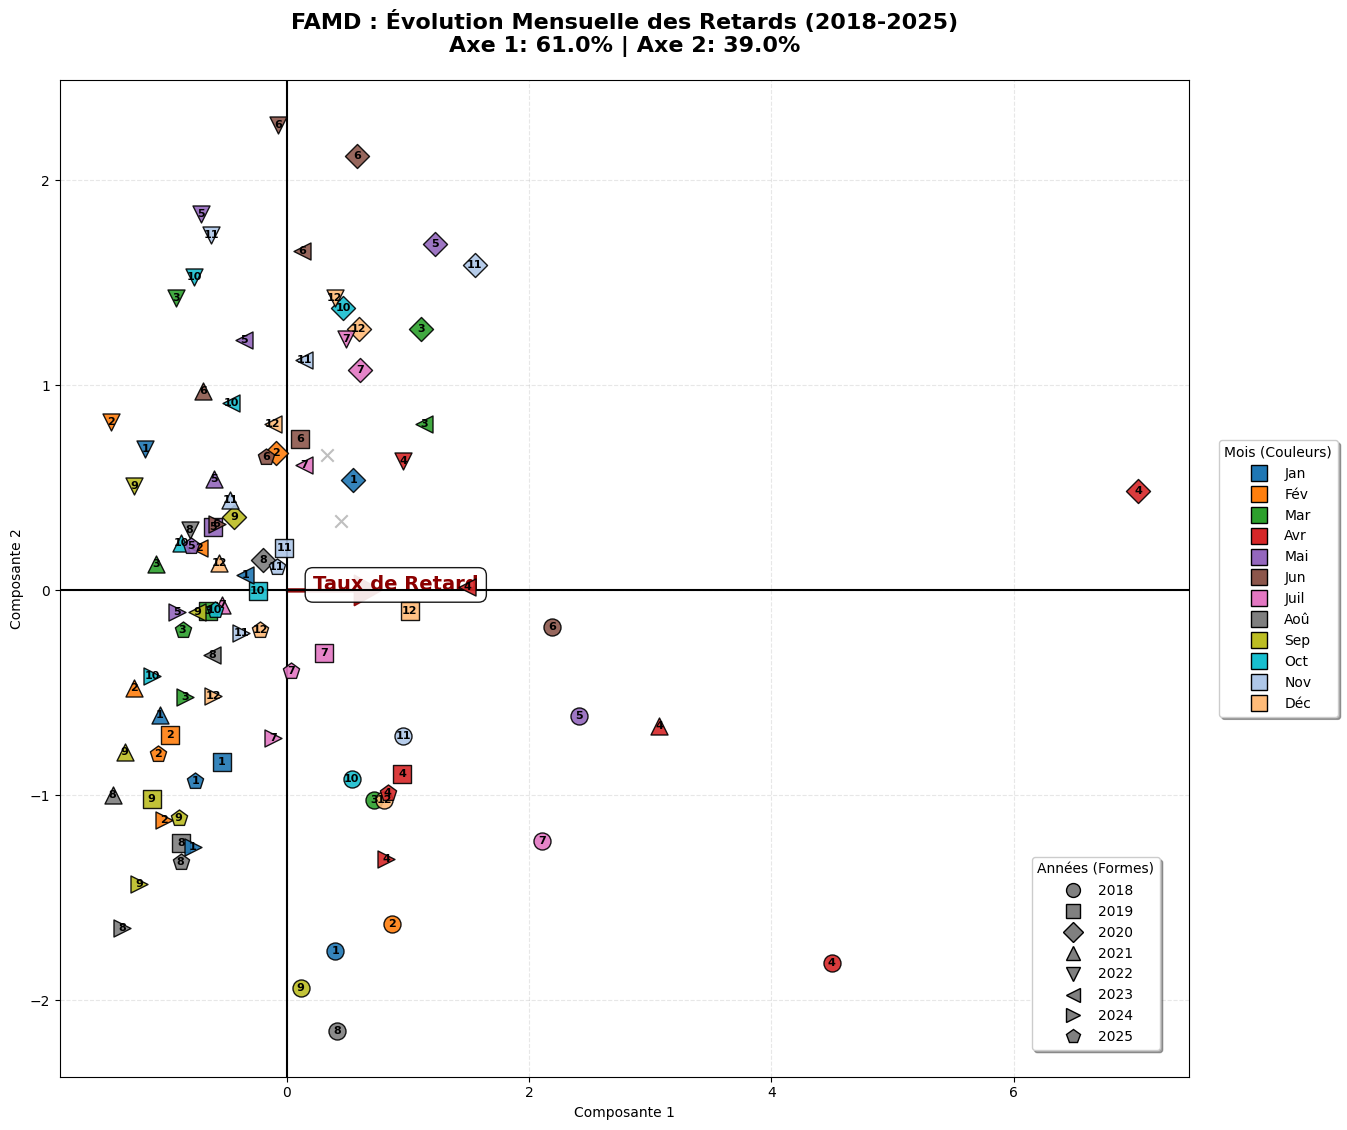

Graphique généré avec formes par année et légende discrète par mois.


In [37]:
# --- 1. PRÉPARATION DES DONNÉES (Identique) ---
df_famd = data.copy()

df_famd['date_str'] = df_famd['date'].astype(str)
df_famd['annee_var'] = df_famd['date_str'].str[:4].astype('object') 
df_famd['mois_var'] = df_famd['date_str'].str.split('-').str[1].astype('object') 
df_famd['individu'] = df_famd['mois_var'] + '-' + df_famd['annee_var']

agg_data = df_famd.groupby(['individu', 'mois_var', 'annee_var']).agg({
    'arr_late_trains': 'sum',
    'cancelled_trains': 'sum',
    'planned_trains': 'sum'
}).reset_index()

agg_data['proportion_retard'] = (agg_data['arr_late_trains'] + agg_data['cancelled_trains']) / agg_data['planned_trains'].replace(0, np.nan)
agg_data['proportion_retard'] = agg_data['proportion_retard'].fillna(0).astype('float')

df_final = agg_data[['individu', 'mois_var', 'annee_var', 'proportion_retard']].copy()
df_final.set_index('individu', inplace=True)

# --- 2. LANCEMENT DE LA FAMD ---
famd = prince.FAMD(n_components=2, n_iter=10, copy=True, check_input=True, random_state=42)
famd = famd.fit(df_final)

# --- 3. RÉCUPÉRATION DES COORDONNÉES (Syntaxe Mixte) ---
coords_ind = famd.row_coordinates(df_final).copy()
coords_ind.columns = ['Axe 1', 'Axe 2']

coords_var = famd.column_coordinates_.copy()
coords_var.columns = ['Axe 1', 'Axe 2']

# Préparation des données pour le graphique
coords_ind['annee_num'] = coords_ind.index.str.split('-').str[1].astype(int)
coords_ind['mois_num'] = coords_ind.index.str.split('-').str[0].astype(int)
coords_ind['annee_str'] = coords_ind.index.str.split('-').str[1]
coords_ind['mois_str'] = coords_ind.index.str.split('-').str[0]

# Séparation Quantitatif / Qualitatif
if 'proportion_retard' in coords_var.index:
    var_quant = coords_var.loc[['proportion_retard']]
    var_qual = coords_var.drop('proportion_retard')
else:
    var_quant = coords_var.iloc[[0]] 
    var_qual = coords_var.iloc[1:]

# --- 4. VISUALISATION MODIFIÉE ---
plt.figure(figsize=(16, 12))

# A. Définition des styles
# 1. Marqueurs par Année (Cycle pour gérer plus de 10 années si besoin)
liste_marqueurs = ['o', 's', 'D', '^', 'v', '<', '>', 'p', 'h', '*', 'X', 'd']
annees_uniques = sorted(coords_ind['annee_str'].unique())
dict_marqueurs = {annee: liste_marqueurs[i % len(liste_marqueurs)] for i, annee in enumerate(annees_uniques)}

# 2. Couleurs par Mois (Palette qualitative pour 12 mois)
# On utilise une palette étendue ou on cycle sur tab10/Set1
mois_uniques = sorted(coords_ind['mois_num'].unique())
# Création d'une palette de 12 couleurs distinctes
cmap_mois = plt.get_cmap('tab10')
# Pour avoir 12 couleurs, on combine tab10 et une autre ou on utilise une liste manuelle
couleurs_mois = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', 
    '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#aec7e8', '#ffbb78'
] 
dict_couleurs_mois = {mois: couleurs_mois[(mois-1) % 12] for mois in mois_uniques}
noms_mois = {1: 'Jan', 2: 'Fév', 3: 'Mar', 4: 'Avr', 5: 'Mai', 6: 'Jun', 
             7: 'Juil', 8: 'Aoû', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Déc'}

# B. Tracé des Variables (Fond)
# 1. Flèche Variable QUANTITATIVE (Rouge)
x_q, y_q = var_quant['Axe 1'].iloc[0], var_quant['Axe 2'].iloc[0]
plt.arrow(0, 0, x_q, y_q, color='darkred', alpha=0.9, width=0.015, head_width=0.15, length_includes_head=True, zorder=1)
plt.text(x_q*1.15, y_q*1.15, "Taux de Retard", color='darkred', fontsize=14, fontweight='bold', 
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9), zorder=2, ha='center')

# 2. Points Variables QUALITATIVES (Gris foncé pour ne pas gêner)
for idx, row in var_qual.iterrows():
    x, y = row['Axe 1'], row['Axe 2']
    label = str(idx)
    if 'annee_var' in label or 'mois_var' in label:
        plt.scatter(x, y, c='gray', s=80, marker='x', alpha=0.5, zorder=1)
        # Optionnel : afficher les labels des modalités si nécessaire
        # plt.text(x*1.1, y*1.1, label.replace('annee_var_', '').replace('mois_var_', ''), color='gray', fontsize=9, alpha=0.7)

# C. Tracé des Individus (Boucle par Année pour changer la forme)
for annee in annees_uniques:
    df_annee = coords_ind[coords_ind['annee_str'] == annee]
    
    marker = dict_marqueurs[annee]
    
    # On trace les points de cette année, la couleur dépend du mois
    for i, row in df_annee.iterrows():
        mois = row['mois_num']
        couleur = dict_couleurs_mois[mois]
        
        plt.scatter(row['Axe 1'], row['Axe 2'], 
                    c=couleur, 
                    marker=marker, 
                    s=150, 
                    edgecolors='black', 
                    linewidth=1, 
                    alpha=0.9, 
                    zorder=10,
                    label=f"{annee}" if mois == 1 else "") # Légende uniquement sur le premier point de l'année

    # Annotation du numéro du mois sur chaque point
    for i, row in df_annee.iterrows():
        plt.text(row['Axe 1'], row['Axe 2'], str(int(row['mois_num'])), 
                 fontsize=8, ha='center', va='center', fontweight='bold', color='black', zorder=11)

# D. Légendes Personnalisées

# 1. Légende des Années (Formes) - En bas
handles_annees = [plt.Line2D([0], [0], marker=dict_marqueurs[a], color='w', label=a,
                       markerfacecolor='gray', markersize=10, markeredgecolor='black') for a in annees_uniques]
leg_annees = plt.legend(handles=handles_annees, title="Années (Formes)", loc='lower right', bbox_to_anchor=(0.98, 0.02), frameon=True, fancybox=True, shadow=True)
plt.gca().add_artist(leg_annees) # Garde la légende active

# 2. Légende des Mois (Couleurs) - À droite, discrète (cases)
handles_mois = [plt.Line2D([0], [0], marker='s', color='w', label=noms_mois[m],
                     markerfacecolor=dict_couleurs_mois[m], markersize=12, markeredgecolor='black') for m in range(1, 13)]
leg_mois = plt.legend(handles=handles_mois, title="Mois (Couleurs)", loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True, fancybox=True, shadow=True)

# E. Titres et Axes
total_inertia = famd.eigenvalues_.sum()
inertie_1 = famd.eigenvalues_[0] / total_inertia
inertie_2 = famd.eigenvalues_[1] / total_inertia

plt.title(f"FAMD : Évolution Mensuelle des Retards (2018-2025)\nAxe 1: {inertie_1:.1%} | Axe 2: {inertie_2:.1%}", fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f"Composante 1")
plt.ylabel(f"Composante 2")
plt.axhline(0, color='black', linewidth=1.5)
plt.axvline(0, color='black', linewidth=1.5)
plt.grid(True, linestyle='--', alpha=0.3)

# Pas de colorbar globale car on a une légende discrète

plt.tight_layout(rect=[0, 0.05, 0.85, 1]) # Laisser de la place à droite pour la légende des mois

plt.show()
print("Graphique généré avec formes par année et légende discrète par mois.")


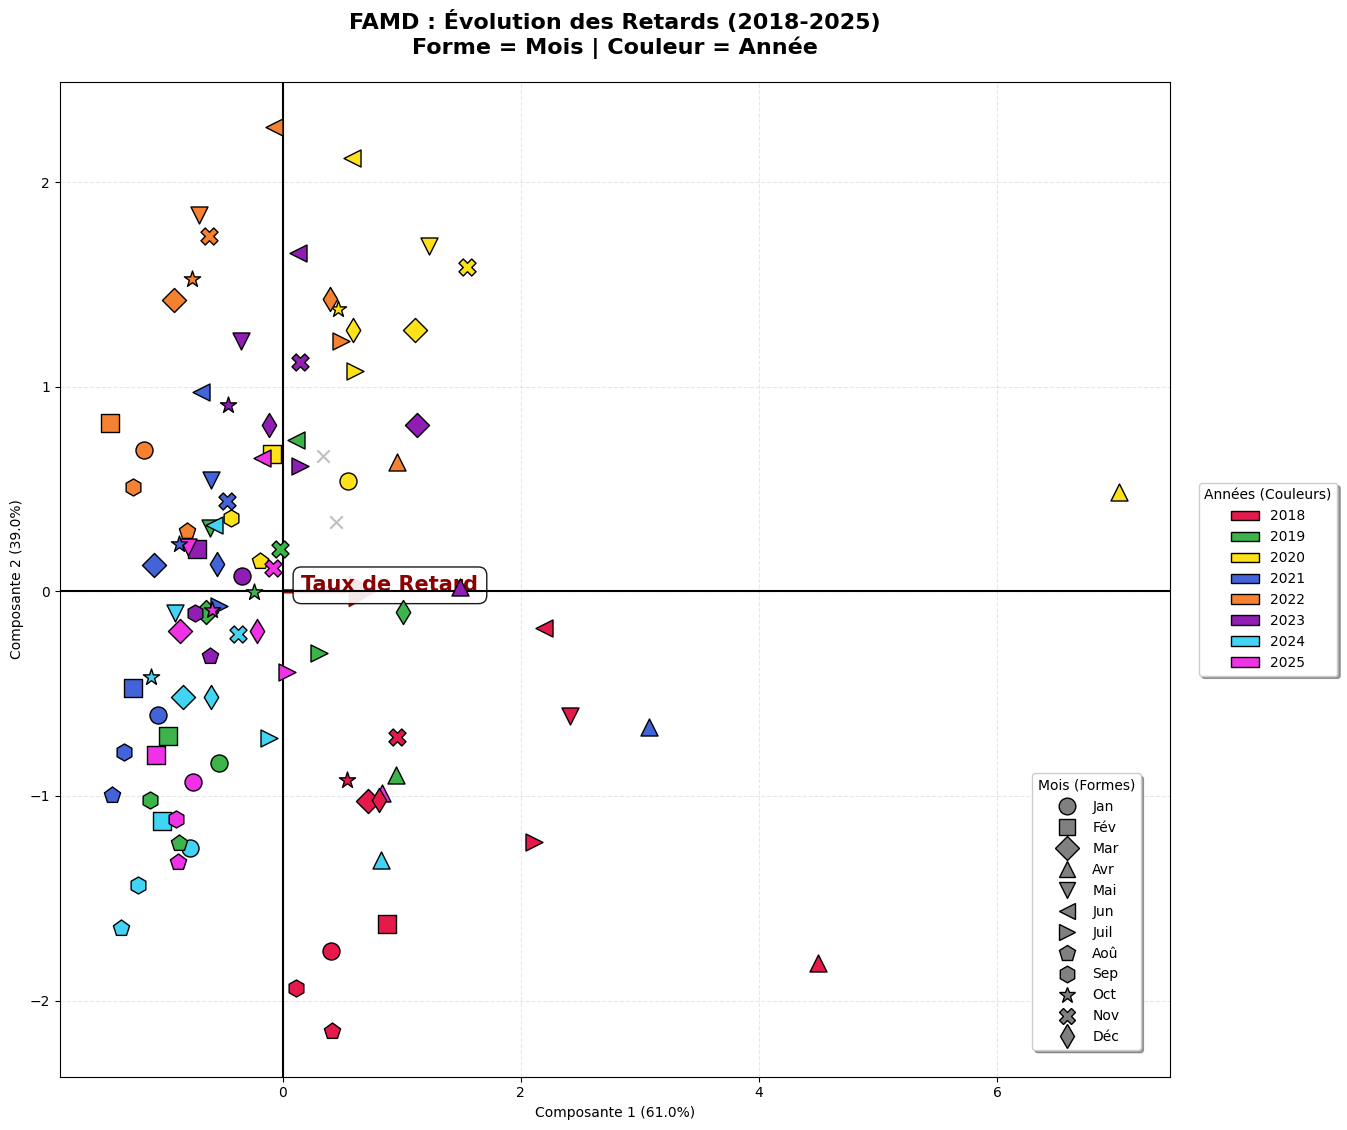

In [42]:
# --- 1. PRÉPARATION DES DONNÉES ---
df_famd = data.copy()

df_famd['date_str'] = df_famd['date'].astype(str)
df_famd['annee_var'] = df_famd['date_str'].str[:4].astype('object') 
df_famd['mois_var'] = df_famd['date_str'].str.split('-').str[1].astype('object') 
df_famd['individu'] = df_famd['mois_var'] + '-' + df_famd['annee_var']

agg_data = df_famd.groupby(['individu', 'mois_var', 'annee_var']).agg({
    'arr_late_trains': 'sum',
    'cancelled_trains': 'sum',
    'planned_trains': 'sum'
}).reset_index()

agg_data['proportion_retard'] = (agg_data['arr_late_trains'] + agg_data['cancelled_trains']) / agg_data['planned_trains'].replace(0, np.nan)
agg_data['proportion_retard'] = agg_data['proportion_retard'].fillna(0).astype('float')

df_final = agg_data[['individu', 'mois_var', 'annee_var', 'proportion_retard']].copy()
df_final.set_index('individu', inplace=True)

# --- 2. LANCEMENT DE LA FAMD ---
famd = prince.FAMD(n_components=2, n_iter=10, copy=True, check_input=True, random_state=42)
famd = famd.fit(df_final)

# --- 3. RÉCUPÉRATION DES COORDONNÉES ---
coords_ind = famd.row_coordinates(df_final).copy()
coords_ind.columns = ['Axe 1', 'Axe 2']

coords_var = famd.column_coordinates_.copy()
coords_var.columns = ['Axe 1', 'Axe 2']

coords_ind['annee_num'] = coords_ind.index.str.split('-').str[1].astype(int)
coords_ind['mois_num'] = coords_ind.index.str.split('-').str[0].astype(int)
coords_ind['annee_str'] = coords_ind.index.str.split('-').str[1]
coords_ind['mois_str'] = coords_ind.index.str.split('-').str[0]

if 'proportion_retard' in coords_var.index:
    var_quant = coords_var.loc[['proportion_retard']]
    var_qual = coords_var.drop('proportion_retard')
else:
    var_quant = coords_var.iloc[[0]] 
    var_qual = coords_var.iloc[1:]

# --- 4. VISUALISATION (COULEURS VIVES UNIQUEMENT) ---
plt.figure(figsize=(16, 12))

# A. DÉFINITION DES STYLES

# 1. COULEURS VIVES PAR ANNÉE (Palette personnalisée saturée)
couleurs_vives_annees = [
    '#E6194B', # Rouge vif
    '#3CB44B', # Vert vif
    '#FFE119', # Jaune pur
    '#4363D8', # Bleu royal
    '#F58231', # Orange vif
    '#911EB4', # Violet pur
    '#42D4F4', # Cyan électrique
    '#F032E6'  # Magenta
]

annees_uniques = sorted(coords_ind['annee_str'].unique())
dict_couleurs_annees = {annee: couleurs_vives_annees[i % len(couleurs_vives_annees)] for i, annee in enumerate(annees_uniques)}

# 2. FORMES PAR MOIS
liste_marqueurs_mois = ['o', 's', 'D', '^', 'v', '<', '>', 'p', 'h', '*', 'X', 'd']
mois_uniques = sorted(coords_ind['mois_num'].unique())
dict_marqueurs_mois = {mois: liste_marqueurs_mois[(mois-1) % len(liste_marqueurs_mois)] for mois in mois_uniques}

noms_mois = {1: 'Jan', 2: 'Fév', 3: 'Mar', 4: 'Avr', 5: 'Mai', 6: 'Jun', 
             7: 'Juil', 8: 'Aoû', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Déc'}

# B. TRACÉ DES VARIABLES (Fond)
# 1. Flèche Variable QUANTITATIVE
x_q, y_q = var_quant['Axe 1'].iloc[0], var_quant['Axe 2'].iloc[0]
plt.arrow(0, 0, x_q, y_q, color='darkred', alpha=0.9, width=0.015, head_width=0.15, length_includes_head=True, zorder=1)
plt.text(x_q*1.15, y_q*1.15, "Taux de Retard", color='darkred', fontsize=15, fontweight='bold', 
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9), zorder=2, ha='center')

# 2. Points Variables QUALITATIVES
for idx, row in var_qual.iterrows():
    x, y = row['Axe 1'], row['Axe 2']
    plt.scatter(x, y, c='gray', s=80, marker='x', alpha=0.5, zorder=1)

# C. TRACÉ DES INDIVIDUS (Boucle par MOIS)
# Pas de texte, pas de fond, juste les points colorés
for mois in mois_uniques:
    df_mois = coords_ind[coords_ind['mois_num'] == mois]
    marker = dict_marqueurs_mois[mois]
    label_mois = noms_mois[mois]
    
    for i, row in df_mois.iterrows():
        annee = row['annee_str']
        couleur = dict_couleurs_annees[annee]
        
        plt.scatter(row['Axe 1'], row['Axe 2'], 
                    c=couleur, 
                    marker=marker, 
                    s=150, 
                    edgecolors='black', 
                    linewidth=1, 
                    alpha=1.0, 
                    zorder=10,
                    label=f"{annee}" if mois == 1 else "") # Légende uniquement sur le premier point de l'année

# D. LÉGENDES

# 1. Légende des Mois (Formes) - En bas
handles_mois = [plt.Line2D([0], [0], marker=dict_marqueurs_mois[m], color='w', label=noms_mois[m],
                     markerfacecolor='gray', markersize=12, markeredgecolor='black') for m in range(1, 13)]
leg_mois = plt.legend(handles=handles_mois, title="Mois (Formes)", loc='lower right', bbox_to_anchor=(0.98, 0.02), frameon=True, fancybox=True, shadow=True)
plt.gca().add_artist(leg_mois)

# 2. Légende des Années (Couleurs Vives) - À droite
from matplotlib.patches import Patch
handles_annees = [Patch(facecolor=dict_couleurs_annees[a], edgecolor='black', label=a) for a in annees_uniques]
leg_annees = plt.legend(handles=handles_annees, title="Années (Couleurs)", loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True, fancybox=True, shadow=True)

# E. TITRES ET AXES
total_inertia = famd.eigenvalues_.sum()
inertie_1 = famd.eigenvalues_[0] / total_inertia
inertie_2 = famd.eigenvalues_[1] / total_inertia

plt.title(f"FAMD : Évolution des Retards (2018-2025)\nForme = Mois | Couleur = Année", fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f"Composante 1 ({inertie_1:.1%})")
plt.ylabel(f"Composante 2 ({inertie_2:.1%})")
plt.axhline(0, color='black', linewidth=1.5)
plt.axvline(0, color='black', linewidth=1.5)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout(rect=[0, 0.05, 0.85, 1])

plt.show()

rajouter les numéros des mois
enleve avril 2020 pour mieux voir les autres
relier les points par années (petits graphs par années ou dashboard)

## Analyse de l'année 2018

Données filtrées : 1560 lignes pour l'année 2018.

Matrice de contingence Mensuelle 2018 :
retard        Jamais  Rarement  Régulièrement  Souvent
periode_mois                                          
2018-01            1        61             68        0
2018-02            3        26             94        7
2018-03            2        57             70        1
2018-04            2         2             38       88
2018-05            1         3             68       58
2018-06            0         7             91       32
2018-07            0         8            102       20
2018-08            3        45             80        2
2018-09            4        61             64        1
2018-10            5        57             68        0
2018-11            2        46             80        2
2018-12            2        61             66        1


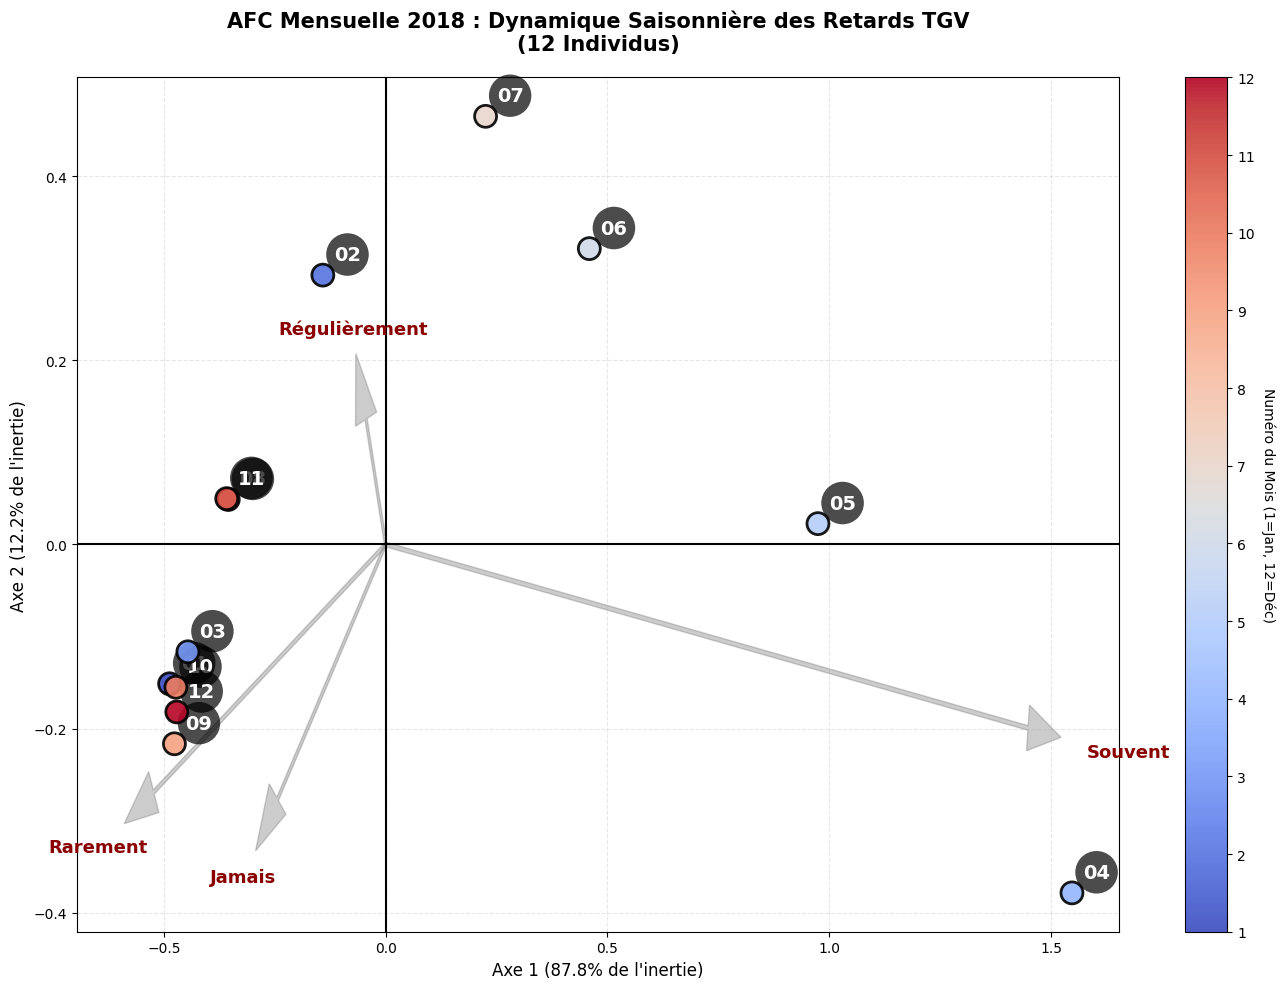


--- Analyse 2018 ---
L'axe 1 explique 87.8% des variations entre les mois de 2018.
L'axe 2 explique 12.2% des variations entre les mois de 2018.
Observez si les mois se suivent chronologiquement (saisonnalité forte) ou s'ils sont dispersés (aléatoire).


In [9]:
#AFC sur année 2018 pour chaque mois (12 individus)
# --- 7. AFC SPÉCIFIQUE POUR L'ANNÉE 2018 (12 Individus : les mois) ---

# A. Filtrage des données pour ne garder que 2018
# On s'assure d'extraire l'année pour filtrer proprement
data['annee_check'] = data['date'].astype(str).str[:4]
data_2018 = data[data['annee_check'] == '2018'].copy()

if data_2018.empty:
    raise ValueError("Aucune donnée trouvée pour l'année 2018. Vérifiez vos dates.")

print(f"Données filtrées : {len(data_2018)} lignes pour l'année 2018.")

# B. Création de la colonne 'mois' pour l'affichage
# Si votre colonne 'date' est "2018-04", on garde tout. 
# Si vous voulez un nom de mois (Avril), il faudrait un mapping, mais gardons le format date pour l'instant.
# Pour l'AFC, l'individu est le mois.
data_2018['periode_mois'] = data_2018['date'].astype(str)

# C. Création de la matrice de contingence par MOIS (pour 2018 uniquement)
matrice_2018 = data_2018.groupby(['periode_mois', 'retard']).size().unstack(fill_value=0)

# Réordonner chronologiquement (si le format est YYYY-MM, le tri alpha fonctionne)
matrice_2018 = matrice_2018.reindex(sorted(matrice_2018.index))

print("\nMatrice de contingence Mensuelle 2018 :")
print(matrice_2018)

# D. Lancement de l'AFC sur les données de 2018
afc_2018 = prince.CA(n_components=2, n_iter=10, copy=True, check_input=True, random_state=42)
afc_2018 = afc_2018.fit(matrice_2018)

# E. Calcul des inerties
total_inertia_2018 = afc_2018.eigenvalues_.sum()
inertie_m1 = afc_2018.eigenvalues_[0] / total_inertia_2018
inertie_m2 = afc_2018.eigenvalues_[1] / total_inertia_2018

# F. Visualisation
plt.figure(figsize=(14, 10))

# 1. Récupérer les coordonnées des individus (les mois de 2018)
coords_mois = afc_2018.row_coordinates(matrice_2018)
coords_mois.columns = ['Axe 1', 'Axe 2']

# 2. Récupérer les coordonnées des variables (les catégories de retard)
coords_vars_2018 = afc_2018.column_coordinates(matrice_2018)
coords_vars_2018.columns = ['Axe 1', 'Axe 2']

# 3. Tracer les flèches des variables (Catégories) en fond
for i, txt in enumerate(coords_vars_2018.index):
    x = coords_vars_2018['Axe 1'].iloc[i]
    y = coords_vars_2018['Axe 2'].iloc[i]
    # Flèche depuis l'origine
    plt.arrow(0, 0, x, y, color='gray', alpha=0.4, width=0.005, head_width=0.05, length_includes_head=True)
    # Nom de la catégorie au bout de la flèche
    plt.text(x*1.1, y*1.1, txt, color='darkred', fontsize=13, fontweight='bold', ha='center')

# 4. Tracer les points des MOIS par dessus
# On crée un numéro de mois (1 à 12) pour la couleur, basé sur l'index
# On extrait le mois de la chaîne "2018-04" -> "04" -> 4
coords_mois['mois_num'] = coords_mois.index.str.split('-').str[1].astype(int)

scatter_mois = plt.scatter(
    coords_mois['Axe 1'], 
    coords_mois['Axe 2'], 
    c=coords_mois['mois_num'], 
    cmap='coolwarm',  # Palette allant du froid (janvier) au chaud (décembre) ou inversement
    s=250, 
    alpha=0.9, 
    edgecolors='black', 
    linewidth=2,
    zorder=10,
    label='Mois 2018'
)

# 5. Ajouter le label du mois à côté du point (Décalé pour lisibilité)
for i, txt in enumerate(coords_mois.index):
    # On nettoie le label pour n'afficher que le mois si possible, ou la date complète
    # Ex: "2018-04" -> on pourrait afficher "Avril" si on avait un dictionnaire, 
    # mais affichons "04" ou la date complète raccourcie.
    label_affiche = txt.split('-')[1] # Affiche juste le numéro du mois "04"
    
    x_val = coords_mois['Axe 1'].iloc[i]
    y_val = coords_mois['Axe 2'].iloc[i]
    
    plt.annotate(f"{label_affiche}", (x_val, y_val), 
                 xytext=(8, 8),          # Décalage de 8 points
                 textcoords='offset points', 
                 ha='left', 
                 va='bottom', 
                 fontsize=14, 
                 fontweight='bold', 
                 color='white',
                 bbox=dict(boxstyle='circle,pad=0.4', facecolor='black', alpha=0.7, edgecolor='none'))

plt.title("AFC Mensuelle 2018 : Dynamique Saisonnière des Retards TGV\n(12 Individus)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel(f"Axe 1 ({inertie_m1:.1%} de l'inertie)", fontsize=12)
plt.ylabel(f"Axe 2 ({inertie_m2:.1%} de l'inertie)", fontsize=12)

# Grille et axes
plt.axhline(0, color='black', linewidth=1.5)
plt.axvline(0, color='black', linewidth=1.5)
plt.grid(True, linestyle='--', alpha=0.3)

# Légende de couleur (Barre des mois)
cbar = plt.colorbar(scatter_mois)
cbar.set_label('Numéro du Mois (1=Jan, 12=Déc)', rotation=270, labelpad=15)
cbar.set_ticks(range(1, 13))

plt.tight_layout()
plt.show()

print(f"\n--- Analyse 2018 ---")
print(f"L'axe 1 explique {inertie_m1:.1%} des variations entre les mois de 2018.")
print(f"L'axe 2 explique {inertie_m2:.1%} des variations entre les mois de 2018.")
print("Observez si les mois se suivent chronologiquement (saisonnalité forte) ou s'ils sont dispersés (aléatoire).")


In [10]:
#Interprétation des résultats de l'AFC :
print("\n--- Interprétation des résultats de l'AFC ---")
print("1. Inertie des axes :")
print(f"   - Axe 1 : {inertie_1:.1%} de l'inertie totale")
print(f"   - Axe 2 : {inertie_2:.1%} de l'inertie totale")
print("\n2. Positionnement des individus (périodes) :")



--- Interprétation des résultats de l'AFC ---
1. Inertie des axes :
   - Axe 1 : 73.1% de l'inertie totale
   - Axe 2 : 26.9% de l'inertie totale

2. Positionnement des individus (périodes) :


https://www.lemonde.fr/economie/article/2019/03/01/la-greve-a-degrade-les-comptes-de-la-sncf-en-2018_5429869_3234.html



# Analyse d'une ligne à travers le temps

Nous nous intéressons maintenant à la ligne TOULOUSE-MATABIAU / PARIS-MONTPARNASSE pour comprendre comment les retards ont évolué les retards de 2018 à 2025.

In [ ]:
#FMA sur la ligne TOULOUSE-MATABIAU => PARIS-MONTPARNASSE au travers des années

#tableau des individus contenant TOULOUSE-MATABIAU et PARIS-MONTPARNASSE
toulouse_paris = data[
    ((data['dep_station'] == 'TOULOUSE MATABIAU') & (data['arr_station'] == 'PARIS MONTPARNASSE')) |
    ((data['dep_station'] == 'PARIS MONTPARNASSE') & (data['arr_station'] == 'TOULOUSE MATABIAU'))
]
toulouse_paris['year'] = toulouse_paris['date'].str[:4]

# Séparer par sens de circulationhttps://maxhalford.github.io/prince/famd/
toulouse_to_paris = data[(data['dep_station'] == 'TOULOUSE MATABIAU') & (data['arr_station'] == 'PARIS MONTPARNASSE')]
paris_to_toulouse = data[(data['dep_station'] == 'PARIS MONTPARNASSE') & (data['arr_station'] == 'TOULOUSE MATABIAU')]

display(toulouse_to_paris)
display(paris_to_toulouse)



,date,service,dep_station,arr_station,avg_duration,planned_trains,cancelled_trains,dep_late_trains,dep_avg_late,dep_avg_all,...,pct_rolling,pct_station,pct_passengers,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,moy_retard_train_deja_retard,retard
6,2018-01,National,TOULOUSE MATABIAU,PARIS MONTPARNASSE,257,184,0,23,11.221739,1.193931,...,9.090909,4.545455,0.000000,NaN,NaN,NaN,NaN,NaN,9.551449,Rarement
157,2018-02,National,TOULOUSE MATABIAU,PARIS MONTPARNASSE,257,168,3,25,17.838667,2.478788,...,11.111111,2.777778,0.000000,NaN,NaN,NaN,NaN,NaN,16.657455,Régulièrement
294,2018-03,National,TOULOUSE MATABIAU,PARIS MONTPARNASSE,257,183,4,17,4.467647,0.129423,...,25.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1.393198,Régulièrement
416,2018-04,National,TOULOUSE MATABIAU,PARIS MONTPARNASSE,259,150,42,16,6.747917,0.604475,...,28.571429,7.142857,0.000000,NaN,NaN,NaN,NaN,NaN,5.666956,Régulièrement
555,2018-05,National,TOULOUSE MATABIAU,PARIS MONTPARNASSE,258,161,34,10,21.831667,1.696063,...,52.941176,5.882353,0.000000,NaN,NaN,NaN,NaN,NaN,27.306614,Régulièrement
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11331,2025-08,National,TOULOUSE MATABIAU,PARIS MONTPARNASSE,291,221,1,40,13.744167,2.526061,...,1.666667,8.076923,3.205128,NaN,NaN,NaN,NaN,NaN,13.956485,Régulièrement
11360,2025-09,National,TOULOUSE MATABIAU,PARIS MONTPARNASSE,287,214,7,21,18.420635,1.918438,...,7.671840,3.769401,7.804878,NaN,NaN,NaN,NaN,NaN,19.549797,Régulièrement
11490,2025-10,National,TOULOUSE MATABIAU,PARIS MONTPARNASSE,285,222,3,25,29.871333,3.405023,...,4.967949,4.967949,7.211538,NaN,NaN,NaN,NaN,NaN,30.236603,Régulièrement
11710,2025-11,National,TOULOUSE MATABIAU,PARIS MONTPARNASSE,286,176,0,24,41.193750,5.634564,...,12.500000,10.000000,7.500000,NaN,NaN,NaN,NaN,NaN,41.320139,Régulièrement


,date,service,dep_station,arr_station,avg_duration,planned_trains,cancelled_trains,dep_late_trains,dep_avg_late,dep_avg_all,...,pct_rolling,pct_station,pct_passengers,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,moy_retard_train_deja_retard,retard
80,2018-01,National,PARIS MONTPARNASSE,TOULOUSE MATABIAU,257,182,1,38,10.412281,1.958748,...,19.047619,4.761905,0.000000,NaN,NaN,NaN,NaN,NaN,9.381371,Rarement
232,2018-02,National,PARIS MONTPARNASSE,TOULOUSE MATABIAU,257,155,2,52,13.375000,4.366449,...,8.108108,2.702703,0.000000,NaN,NaN,NaN,NaN,NaN,13.015376,Régulièrement
372,2018-03,National,PARIS MONTPARNASSE,TOULOUSE MATABIAU,257,179,4,41,8.367480,1.762762,...,20.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,7.695961,Rarement
394,2018-04,National,PARIS MONTPARNASSE,TOULOUSE MATABIAU,257,148,42,29,10.018966,2.521698,...,30.769231,7.692308,7.692308,NaN,NaN,NaN,NaN,NaN,12.869356,Régulièrement
554,2018-05,National,PARIS MONTPARNASSE,TOULOUSE MATABIAU,257,164,41,13,9.458974,1.040515,...,13.333333,0.000000,6.666667,NaN,NaN,NaN,NaN,NaN,13.126496,Régulièrement
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11213,2025-08,National,PARIS MONTPARNASSE,TOULOUSE MATABIAU,287,228,3,32,15.177083,1.695926,...,4.444444,2.222222,13.333333,NaN,NaN,NaN,NaN,NaN,12.083472,Régulièrement
11433,2025-09,National,PARIS MONTPARNASSE,TOULOUSE MATABIAU,281,210,5,26,38.777564,4.411789,...,4.651163,2.325581,6.976744,NaN,NaN,NaN,NaN,NaN,35.633677,Régulièrement
11560,2025-10,National,PARIS MONTPARNASSE,TOULOUSE MATABIAU,280,217,2,14,16.267857,0.559225,...,5.882353,2.941176,5.882353,NaN,NaN,NaN,NaN,NaN,8.667984,Régulièrement
11609,2025-11,National,PARIS MONTPARNASSE,TOULOUSE MATABIAU,279,169,0,20,13.598333,1.123176,...,6.896552,3.448276,20.689655,NaN,NaN,NaN,NaN,NaN,9.490833,Régulièrement


<Figure size 3000x1600 with 0 Axes>

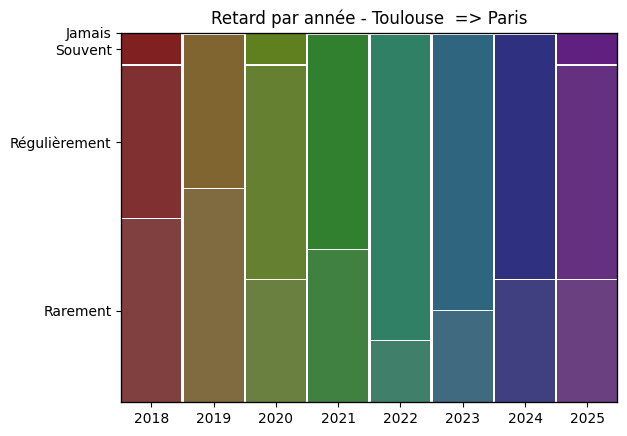

<Figure size 3000x1600 with 0 Axes>

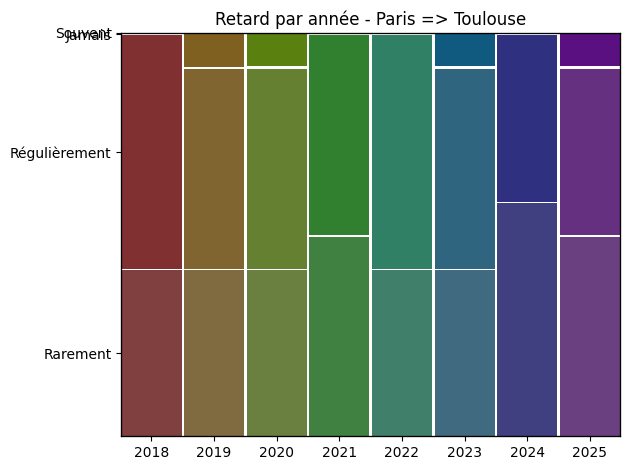

In [24]:
# Extract year from date for both dataframes
toulouse_to_paris['year'] = toulouse_to_paris['date'].str[:4]
paris_to_toulouse['year'] = paris_to_toulouse['date'].str[:4]

# Toulouse to paris
# Convertir 'retard' en catégorie ordonnée
toulouse_to_paris['retard'] = pd.Categorical(
       toulouse_to_paris['retard'],
       categories=['Jamais', 'Rarement', 'Régulièrement', 'Souvent'],
       ordered=True
)

# Créer le mosaic plot
plt.figure(figsize=(30, 16))
mosaic(toulouse_to_paris, ['year', 'retard'], 
          title='Retard par année - Toulouse  => Paris',
          labelizer=lambda k: "")

#Paris to Toulouse
#convertir 'retard' en catégorie ordonnée
paris_to_toulouse['retard'] = pd.Categorical(
       paris_to_toulouse['retard'],
       categories=['Jamais', 'Rarement', 'Régulièrement', 'Souvent'],
       ordered=True
)

#Creer le mosaic plot
plt.figure(figsize=(30, 16))
mosaic(paris_to_toulouse, ['year', 'retard'], 
          title='Retard par année - Paris => Toulouse',
          labelizer=lambda k: "")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

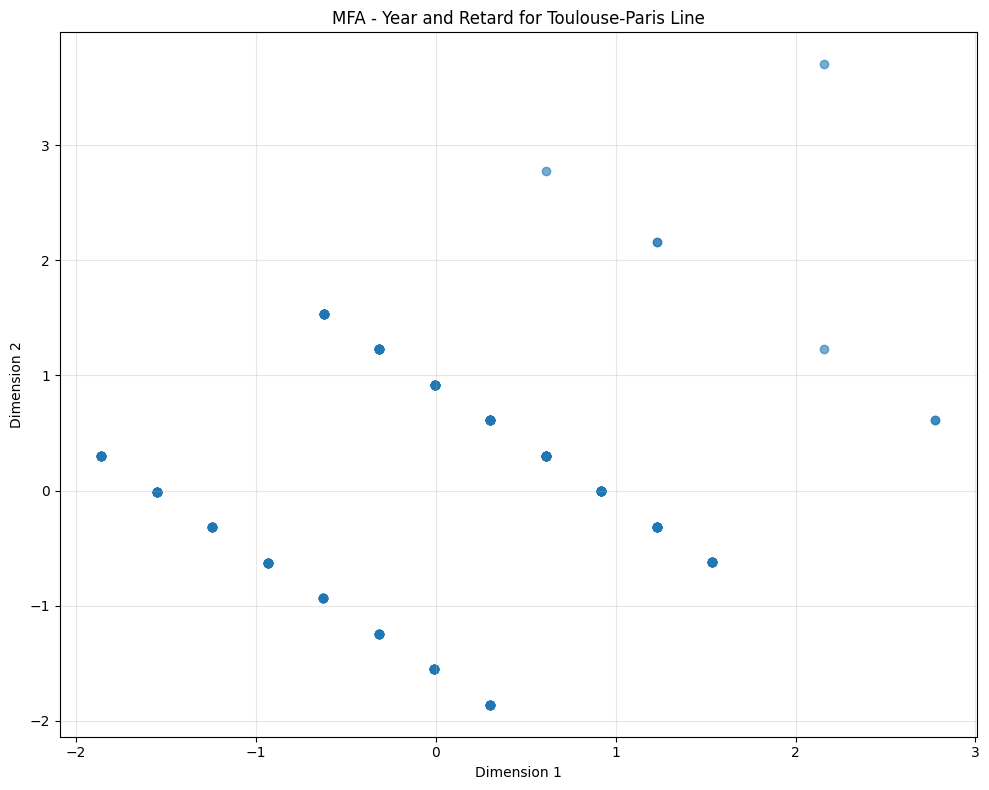

In [ ]:
# Prepare data for MFA - select qualitative variables
mfa_data = toulouse_paris[['year', 'retard']].copy()

# Encode categorical variables to numerical
mfa_data_encoded = mfa_data.copy()
mfa_data_encoded['year'] = pd.factorize(mfa_data_encoded['year'])[0]
mfa_data_encoded['retard'] = pd.factorize(mfa_data_encoded['retard'])[0]

# Define groups (each variable is its own group for MFA)
groups = {'year': ['year'], 'retard': ['retard']}

# Fit MFA with groups parameter
mfa = prince.MFA(
    n_components=2,
    n_iter=3,
    copy=True,
    check_input=True,
    random_state=42
)

mfa.fit(mfa_data_encoded, groups=groups)

# Plot the MFA results using row_coordinates
row_coords = mfa.row_coordinates(mfa_data_encoded)

plt.figure(figsize=(10, 8))
plt.scatter(row_coords.iloc[:, 0], row_coords.iloc[:, 1], alpha=0.6)
plt.xlabel(f'Dimension 1')
plt.ylabel(f'Dimension 2')
plt.title('MFA - Year and Retard for Toulouse-Paris Line')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

